# 04 deep EDA

## Import

In [252]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns

from scipy.stats import chi2_contingency
import itertools

In [3]:
# Für Herrn Waack:
mpl.style.use("seaborn-v0_8-colorblind")

## Dataset & Splits

In [4]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [5]:
df_raw.columns

Index(['target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat',
       'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin',
       'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin',
       'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15', 'ps_ind_16_bin',
       'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03',
       'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat',
       'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat',
       'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'ps_car_11',
       'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01',
       'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06',
       'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11',
       'ps_calc_12', 'ps_calc_13', 'ps_calc_14', 'ps_calc_15_bin',
       'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin',
       'ps_calc_20_bin'],
      

In [6]:
memory_pre = df_raw.memory_usage(deep = True).sum() / 1024**2

In [7]:
# dtypes
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")] 
bin_cols = [col for col in feat_cols if col.endswith("_bin")] 
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

memory_post = df_raw.memory_usage(deep=True).sum() / 1024**2

print(f"{memory_pre:.2f} ; {memory_post:.2f}")

136.25 ; 77.21


In [8]:
idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

In [9]:
pd.Series({
    "raw" : len(df_raw),
    "train" : len(df_train),
    "val" : len(df_val),
    "test" : len(df_test)
})

raw      595212
train    476168
val       59522
test      59522
dtype: int64

## EDA

## Target Verteilung

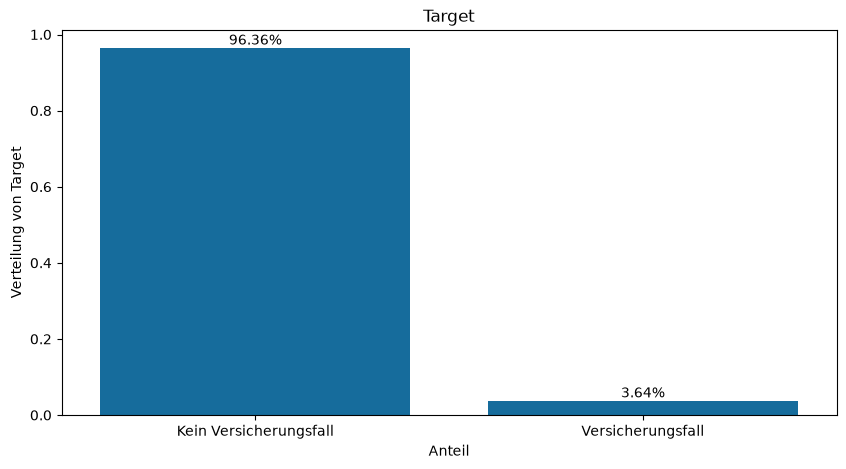

In [10]:
# Target

target_counts = df_raw["target"].value_counts(normalize=True).sort_index()
target_labels = {
    False : "Kein Versicherungsfall",
    True : "Versicherungsfall"
}
bar_labels = target_counts.index.map(target_labels)

fig, ax = plt.subplots(figsize = (10, 5))
sns.barplot(
    x=bar_labels,
    y=target_counts.values, 
    ax=ax
)
ax.set_title("Target")
ax.set_xlabel("Anteil")
ax.set_ylabel("Verteilung von Target")

for x, y in enumerate(target_counts.values):
    ax.text(x, y+0.01, f"{y:.2%}", ha="center")

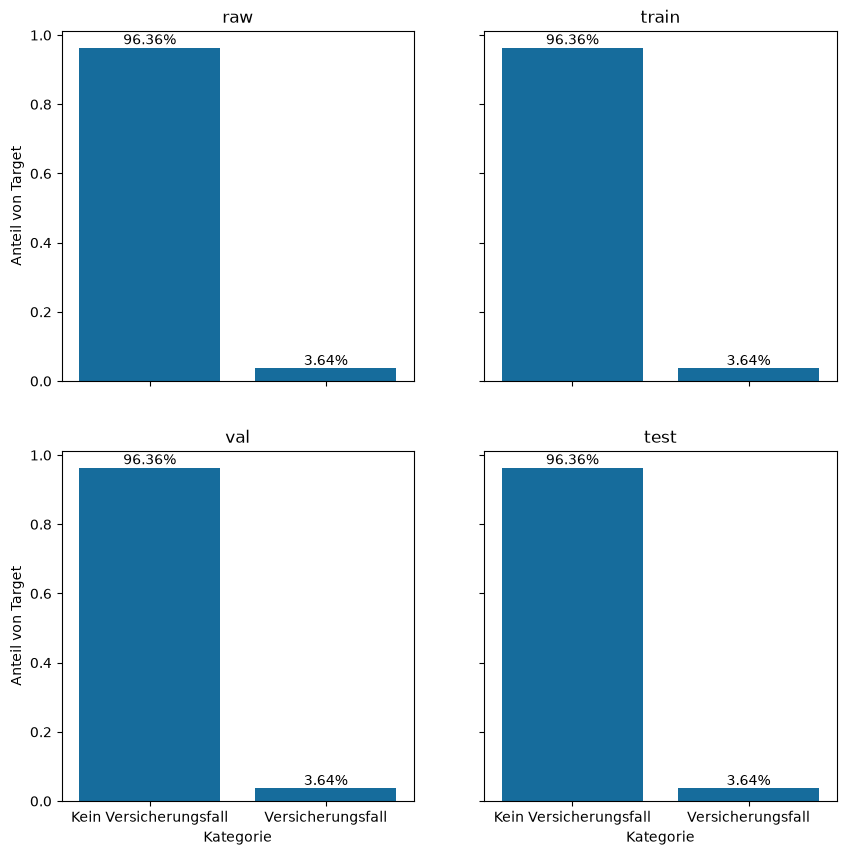

In [11]:
fig, axes = plt.subplots(2,2,figsize=(10,10), sharex=True, sharey=True)

for data_name, data, ax in zip(["raw", "train", "val", "test"], [df_raw, df_train, df_val, df_test], axes.flatten()):
    target_counts = data["target"].value_counts(normalize=True).sort_index()
    target_labels = {
        False : "Kein Versicherungsfall",
        True : "Versicherungsfall"
    }
    bar_labels = target_counts.index.map(target_labels)

    sns.barplot(
        x=bar_labels,
        y=target_counts.values, 
        ax=ax
    )
    ax.set_title(data_name)
    ax.set_xlabel("Kategorie")
    ax.set_ylabel("Anteil von Target")

    for x, y in enumerate(target_counts.values):
        ax.text(x, y+0.01, f"{y:.2%}", ha="center")

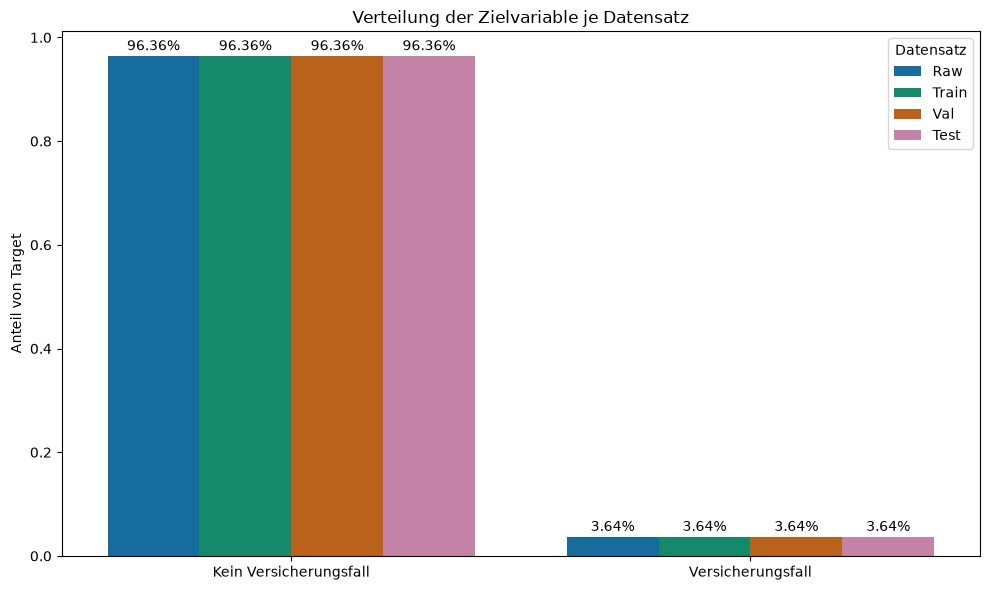

In [12]:
datasets = {
    "Raw": df_raw, 
    "Train": df_train, 
    "Val": df_val, 
    "Test": df_test
}
target_labels = {
    False : "Kein Versicherungsfall",
    True : "Versicherungsfall"
}

rows = []
for name, data in datasets.items():
    counts = data["target"].value_counts(normalize=True).sort_index()
    for value, share in counts.items():
        rows.append({"Datensatz": name, "Target": target_labels[value], "Anteil": share})

plot_df = pd.DataFrame(rows)
plot_df

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=plot_df, 
    x="Target", 
    y="Anteil", 
    hue="Datensatz", 
    ax=ax
)

ax.set_title("Verteilung der Zielvariable je Datensatz")
ax.set_xlabel("")
ax.set_ylabel("Anteil von Target")

for container in ax.containers:
    labels = [f"{v:.2%}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

plt.tight_layout()

## Missing Values

In [256]:
# sanity check wegen kaggle

(df_raw[feat_cols] == -1).sum().sum()

np.int64(0)

(0.0, 0.7435793696195641)

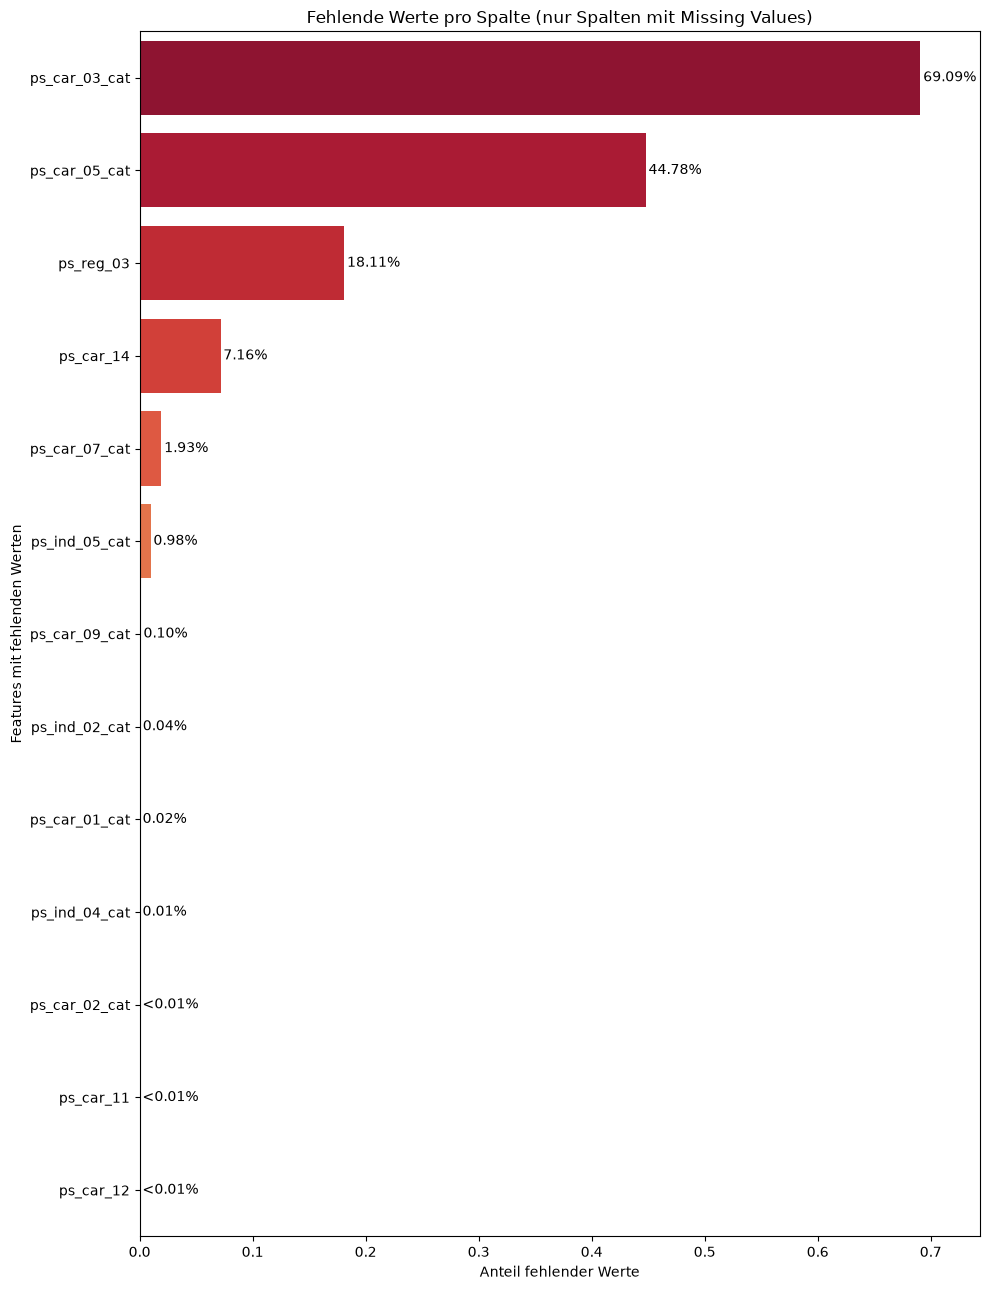

In [62]:
# MVs
miss_share = df_raw[feat_cols].isna().mean().sort_values(ascending=False)
miss_share = miss_share[miss_share > 0]
miss_count = df_raw[feat_cols].isna().sum()
miss_count = miss_count[miss_share.index]


fig, ax = plt.subplots(figsize=(10, max(3, len(miss_share))))
sns.barplot(
    x=miss_share.values, 
    y=miss_share.index, 
    ax=ax, 
    orient="h",
    palette="YlOrRd_r",
    hue=miss_share.index
)
ax.set_xlabel("Anteil fehlender Werte")
ax.set_ylabel("Features mit fehlenden Werten")
ax.set_title("Fehlende Werte pro Spalte (nur Spalten mit Missing Values)")

plt.tight_layout()

for container in ax.containers:
    labels = [f"<0.01%" if v < 0.00001 else f"{v:.2%}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

x_left, x_right = ax.get_xlim()
ax.set_xlim(x_left, x_right*1.025)

(np.float64(8.802864751061394e-07), np.float64(2.637232720129814))

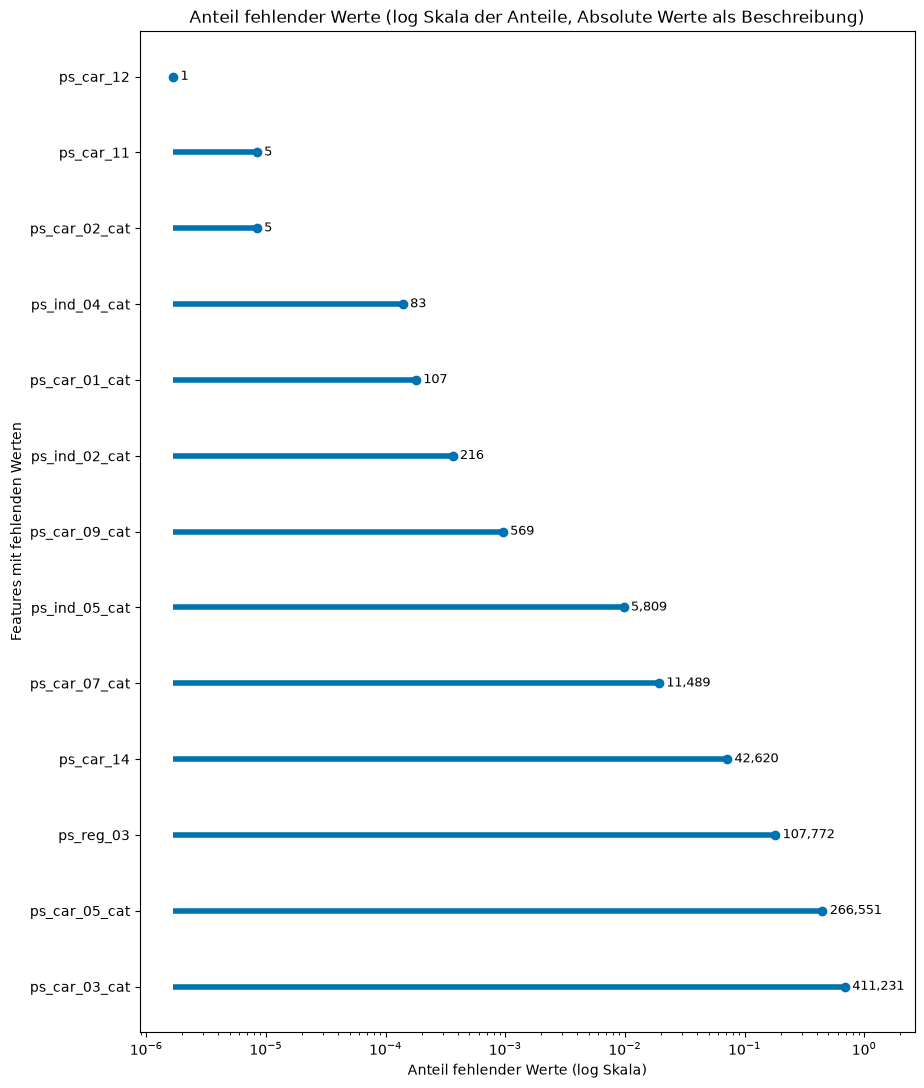

In [ ]:
fig, ax = plt.subplots(figsize=(10, max(3, len(miss_share))))

ax.hlines(
    xmin=miss_share.values.min(),
    xmax=miss_share.values,
    y=miss_share.index,
    linewidth=4,
)
ax.plot(
    miss_share.values, 
    miss_share.index,
    "o"
)
ax.set_xscale("log")
ax.set_xlabel("Anteil fehlender Werte (log Skala)")
ax.set_ylabel("Features mit fehlenden Werten")
ax.set_title("Anteil fehlender Werte (log Skala der Anteile, Absolute Werte als Beschreibung)")

for share, count, label in zip(miss_share.values, miss_count.values, miss_share.index):
    ax.text(share * 1.15, label, f"{count:,}", va="center", fontsize=9)

x_left, x_right = ax.get_xlim()
ax.set_xlim(x_left, x_right*2)

In [93]:
top_miss_cols = miss_share.head(4).index

mv_target_rate_dict = {}
for cols in top_miss_cols:
    is_miss = df_raw[cols].isna()
    rate = df_raw.groupby(is_miss)["target"].mean()
    rate.index = ["vorhanden", "fehlende Werte"]
    mv_target_rate_dict[cols] = rate

mv_target_rate_df = pd.DataFrame(mv_target_rate_dict).T
mv_target_rate_df["diff"] = (mv_target_rate_df["fehlende Werte"] - mv_target_rate_df["vorhanden"]).abs()
mv_target_rate_df 

,vorhanden,fehlende Werte,diff
ps_car_03_cat,0.044809,0.032707,0.012102
ps_car_05_cat,0.040291,0.031709,0.008582
ps_reg_03,0.038228,0.028393,0.009835
ps_car_14,0.036141,0.040427,0.004286


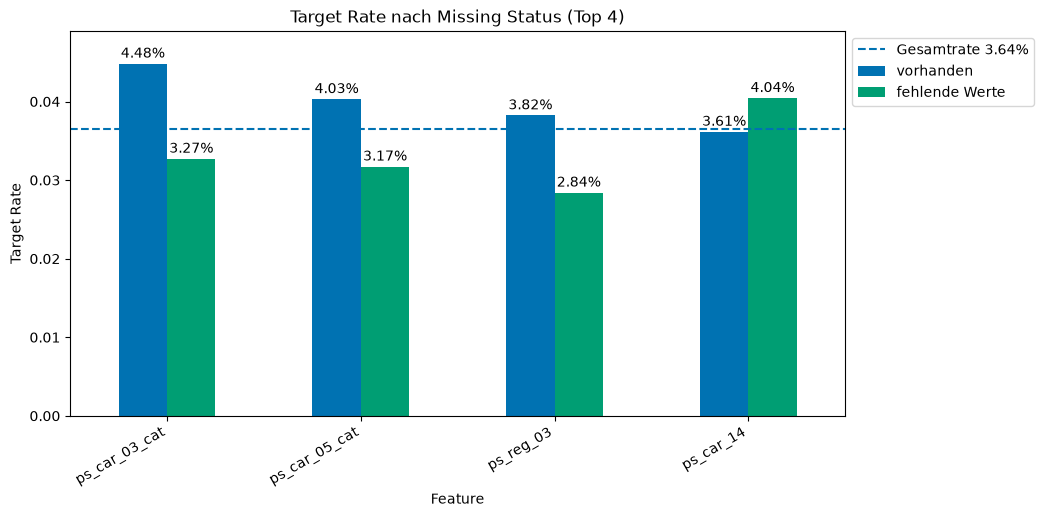

In [94]:
fig, ax = plt.subplots(figsize=(10,5))

mv_target_rate_df[["vorhanden", "fehlende Werte"]].plot(
    kind="bar",
    ax=ax
)

target_mean_rate = df_raw["target"].mean()

ax.axhline(
    target_mean_rate,
    linestyle="--",
    label=f"Gesamtrate {target_mean_rate:.2%}"
)

ax.set_title("Target Rate nach Missing Status (Top 4)")
ax.set_xlabel("Feature")
ax.set_ylabel("Target Rate")
ax.set_ylim(0, 0.049)
ax.legend(bbox_to_anchor=(1, 1))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

for container in ax.containers[:2]:
    labels = [f"{v:.2%}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

In [96]:
miss_by_split = pd.DataFrame({
    "Train" : df_train[feat_cols].isna().mean(),
    "Val" : df_val[feat_cols].isna().mean(),
    "Test" : df_test[feat_cols].isna().mean()
})

miss_by_split = miss_by_split[miss_by_split.sum(axis=1) > 0]
miss_by_split["max abweichung"] = miss_by_split.max(axis=1) - miss_by_split.min(axis=1)
miss_by_split.sort_values("max abweichung", ascending=False)

,Train,Val,Test,max abweichung
ps_reg_03,0.181579,0.180135,0.177884,0.003695
ps_car_05_cat,0.447290,0.450136,0.449800,0.002846
ps_car_14,0.071410,0.073519,0.071251,0.002268
ps_car_03_cat,0.690928,0.689678,0.691879,0.002201
ps_car_07_cat,0.019304,0.019774,0.018817,0.000958
ps_ind_05_cat,0.009707,0.010265,0.009677,0.000588
ps_car_09_cat,0.000930,0.001126,0.000991,0.000195
ps_ind_04_cat,0.000128,0.000202,0.000168,0.000074
ps_ind_02_cat,0.000357,0.000403,0.000370,0.000046
ps_car_12,0.000000,0.000000,0.000017,0.000017


## Category Features

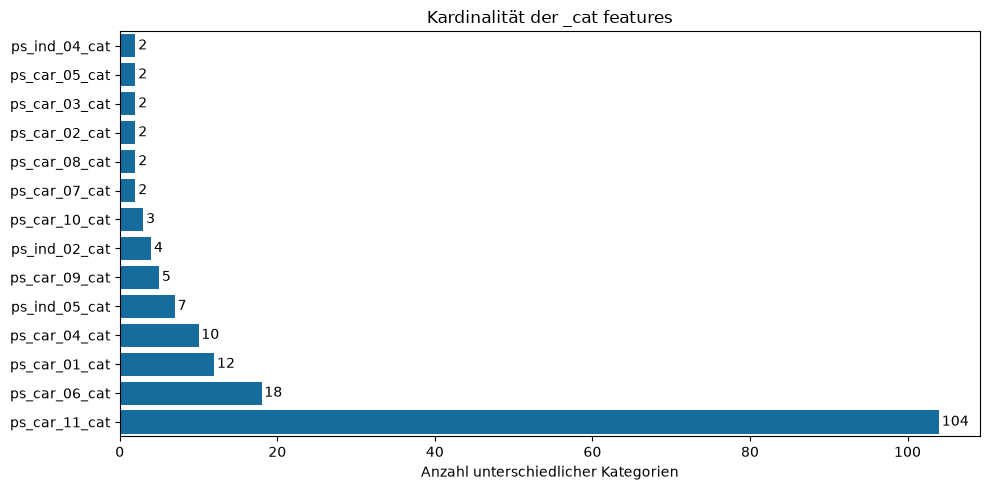

In [107]:
kardinal = df_raw[cat_cols].nunique().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x=kardinal.values,
    y=kardinal.index,
    ax=ax,
    orient="h"
)
ax.set_title("Kardinalität der _cat features")
ax.set_xlabel("Anzahl unterschiedlicher Kategorien")
ax.set_ylabel("")
plt.tight_layout()

for container in ax.containers:
    labels = [f"{v.astype(int)}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

In [125]:
df_raw["ps_car_11_cat"].value_counts(ascending=False)

ps_car_11_cat
104    85083
103    24262
64     22278
87     17106
32     12578
       ...  
58      1464
81      1433
56      1272
18      1233
63      1103
Name: count, Length: 104, dtype: int64

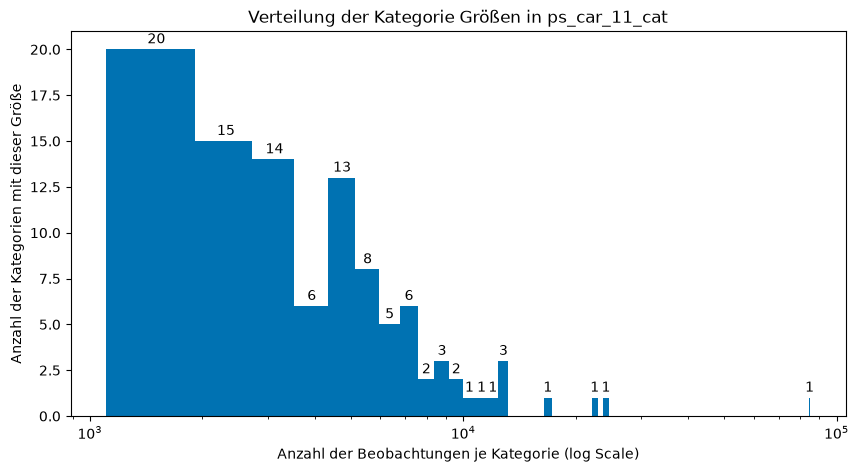

In [141]:
cat_sizes = df_raw["ps_car_11_cat"].value_counts()

fig, ax = plt.subplots(figsize=(10,5))

cat_sizes.plot(
    kind="hist",
    bins=104,
    ax=ax,
    logx=True
)
ax.set_title("Verteilung der Kategorie Größen in ps_car_11_cat")
ax.set_xlabel("Anzahl der Beobachtungen je Kategorie (log Scale)")
ax.set_ylabel("Anzahl der Kategorien mit dieser Größe")

for container in ax.containers:
    labels = ['' if v < 1 else f"{v.astype(int)}" for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=2)

Text(0, 0.5, '')

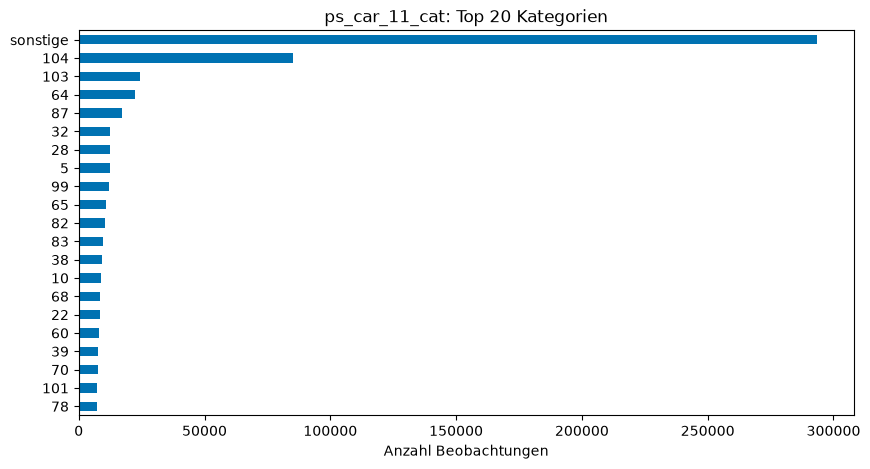

In [146]:
top_n = 20
counts_n = df_raw["ps_car_11_cat"].value_counts()
top = counts_n.head(top_n)
top["sonstige"] = counts_n.iloc[top_n:].sum()

fig, ax = plt.subplots(figsize=(10, 5))

top.sort_values().plot(
    kind="barh",
    ax=ax
)
ax.set_title(f"ps_car_11_cat: Top {top_n} Kategorien")
ax.set_xlabel("Anzahl Beobachtungen")
ax.set_ylabel("")

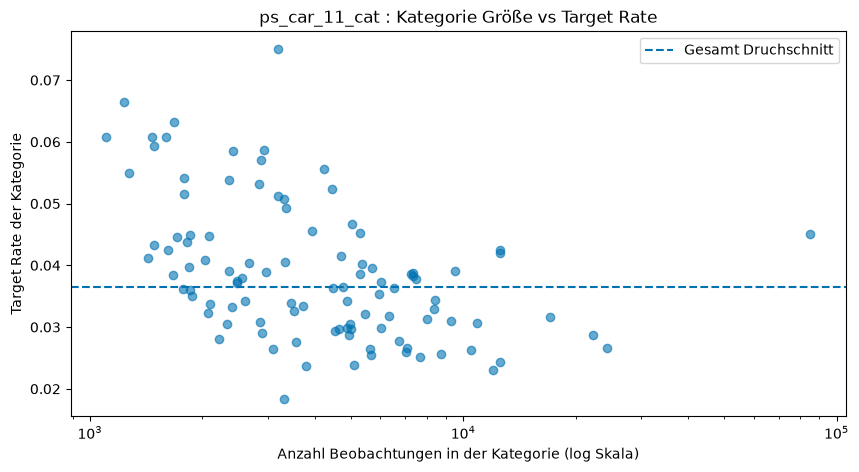

In [149]:
stats_kard = (
    df_raw.groupby("ps_car_11_cat", observed=True)["target"]
    .agg(["mean", "count"])
)

fig, ax = plt.subplots(figsize=(10,5))

ax.scatter(
    stats_kard["count"], 
    stats_kard["mean"],
      alpha=0.6
)
ax.set_xscale("log")
ax.axhline(
    df_raw["target"].mean(),
    linestyle="--",
    label="Gesamt Druchschnitt"
)
ax.set_title("ps_car_11_cat : Kategorie Größe vs Target Rate")
ax.set_xlabel("Anzahl Beobachtungen in der Kategorie (log Skala)")
ax.set_ylabel("Target Rate der Kategorie")
ax.legend()

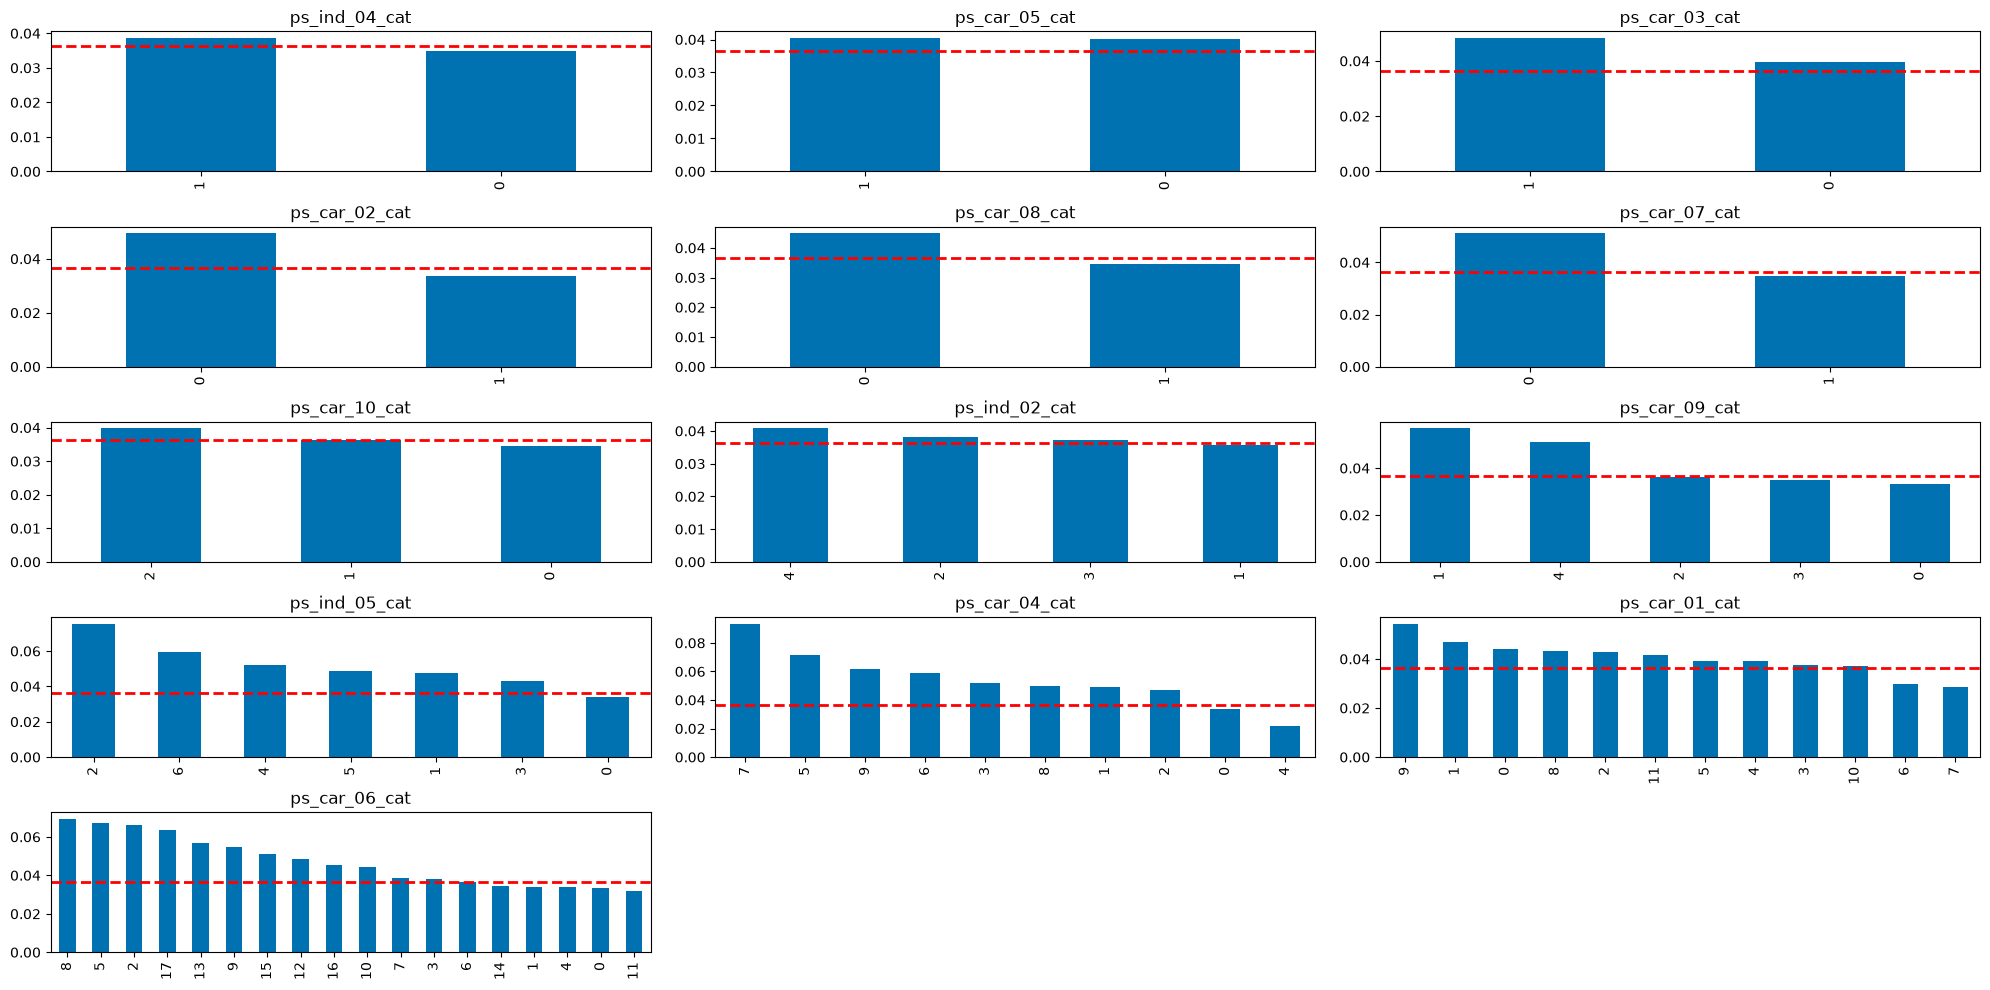

In [157]:
high_kard_thresh = 18
low_kard_cols = kardinal[kardinal <= high_kard_thresh].index
high_kard_cols = kardinal[kardinal > high_kard_thresh].index

kard_cols_grid = 3
kard_rows_grid = int(np.ceil(len(low_kard_cols) / kard_cols_grid))

fig, axes = plt.subplots(kard_rows_grid, kard_cols_grid, figsize=(20,10))

achsen = axes.flatten()
overall_rate = df_raw["target"].mean()

for idx, cols in enumerate(low_kard_cols):
    rates = (
        df_raw
        .groupby(cols, observed=True)["target"]
        .mean()
        .sort_values(ascending=False)
    )
    rates.plot(
        kind="bar",
        ax=achsen[idx]
    )
    achsen[idx].axhline(
        overall_rate,
        linestyle="--",
        linewidth=2,
        color="red"
    )
    achsen[idx].set_title(cols)
    achsen[idx].set_xlabel("")
    achsen[idx].set_ylabel("")
    achsen[idx].tick_params(axis="x")

for n in range(len(low_kard_cols), len(achsen)):
    achsen[n].axis("off")

plt.tight_layout()


## Binäre Features

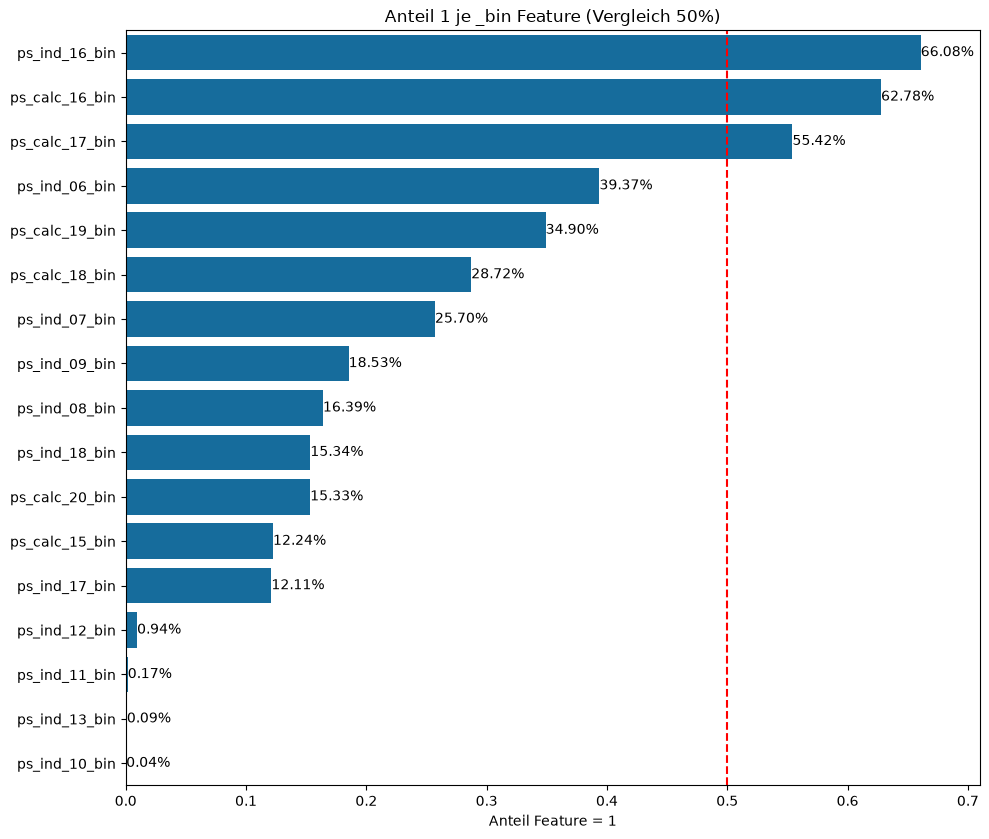

In [180]:
bin_one_share = df_raw[bin_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(3, 0.5* len(bin_one_share))))

sns.barplot(
    x=bin_one_share.values,
    y=bin_one_share.index,
    ax=ax,
    orient="h",
)
ax.axvline(
    0.5, 
    color="red", 
    linestyle="--"
)
ax.set_title("Anteil 1 je _bin Feature (Vergleich 50%)")
ax.set_xlabel("Anteil Feature = 1")
ax.set_ylabel("")
ax.set_xlim(0, 0.71)

for container in ax.containers:
    labels = ["<0.01%" if v < 0.0001 else f"{v:.2%}" for v in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.tight_layout()

In [181]:
bin_target_rate = pd.DataFrame({
    cols : df_raw.groupby(cols, observed=True)["target"].mean() for cols in bin_cols
}).T
bin_target_rate.columns = ["target_rate_bei_0", "target_rate_bei_1"]
bin_target_rate["diff"] = (
    bin_target_rate["target_rate_bei_1"] - bin_target_rate["target_rate_bei_0"]
).abs()

bin_target_rate.sort_values("diff", ascending=False)

,target_rate_bei_0,target_rate_bei_1,diff
ps_ind_17_bin,0.033870,0.055155,0.021285
ps_ind_10_bin,0.036441,0.054054,0.017613
ps_ind_12_bin,0.036305,0.051442,0.015137
ps_ind_13_bin,0.036433,0.051418,0.014985
ps_ind_07_bin,0.032676,0.047350,0.014674
ps_ind_06_bin,0.041585,0.028537,0.013048
ps_ind_16_bin,0.043714,0.032718,0.010996
ps_ind_11_bin,0.036432,0.045680,0.009248
ps_ind_08_bin,0.035357,0.042012,0.006655
ps_ind_09_bin,0.037184,0.033211,0.003973


In [ ]:
def signi(row, p_all, n_tot):
    """Signifikanztest für Anteilswerte, in abhängigkeit von der Gruppenverteilung, ist die differenz durch zufall erklärbar?"""
    share_minor = min(row["anteil_1"], 1 -row["anteil_1"])
    n_minor = n_tot * share_minor
    ste = np.sqrt(p_all * (1 - p_all) / n_minor)
    return row["diff"] > 1.96 * ste

bin_target_rate["anteil_1"] = df_raw[bin_cols].mean()
bin_target_rate["sign"] = bin_target_rate.apply(
    lambda row : signi(row=row, p_all=df_raw["target"].mean(), n_tot=len(df_raw)), axis=1
)
bin_target_rate.sort_values("diff", ascending=False)

,target_rate_bei_0,target_rate_bei_1,diff,anteil_1,sign
ps_ind_17_bin,0.033870,0.055155,0.021285,0.121081,True
ps_ind_10_bin,0.036441,0.054054,0.017613,0.000373,False
ps_ind_12_bin,0.036305,0.051442,0.015137,0.009439,True
ps_ind_13_bin,0.036433,0.051418,0.014985,0.000948,False
ps_ind_07_bin,0.032676,0.047350,0.014674,0.257033,True
ps_ind_06_bin,0.041585,0.028537,0.013048,0.393742,True
ps_ind_16_bin,0.043714,0.032718,0.010996,0.660823,True
ps_ind_11_bin,0.036432,0.045680,0.009248,0.001692,False
ps_ind_08_bin,0.035357,0.042012,0.006655,0.163921,True
ps_ind_09_bin,0.037184,0.033211,0.003973,0.185304,True


Text(0.5, 1.0, 'Korrelation zwischen bin Features')

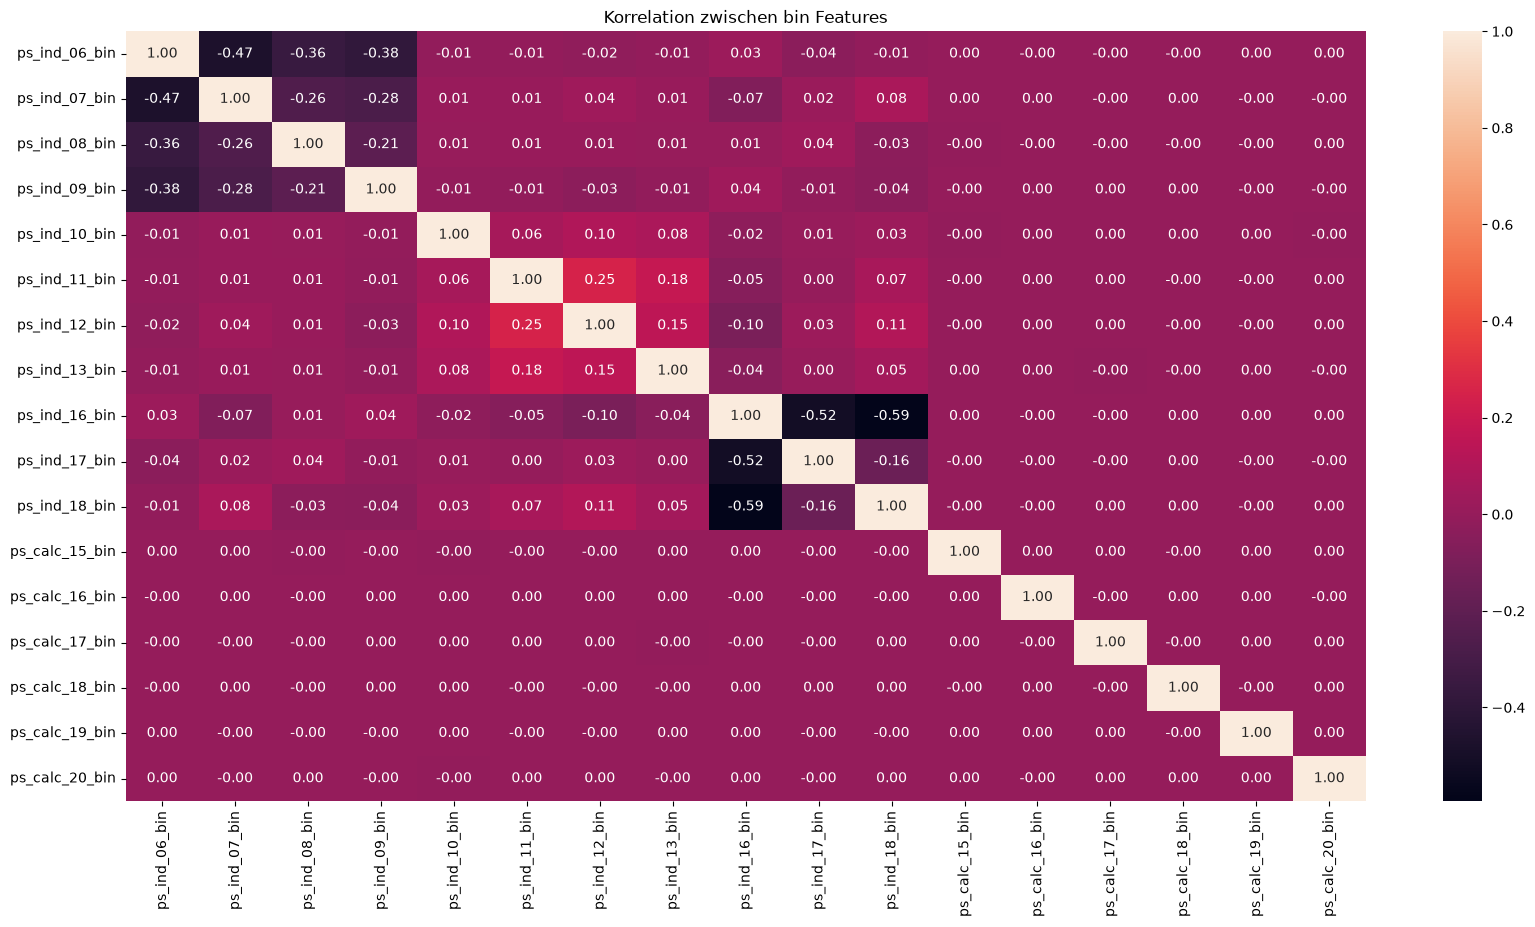

In [192]:
fig, ax = plt.subplots(figsize=(20,10))

sns.heatmap(
    df_raw[bin_cols].astype(float).corr(),
    ax=ax,
    annot=True,
    fmt=".2f"
)
ax.set_title("Korrelation zwischen bin Features")

## Continous Features

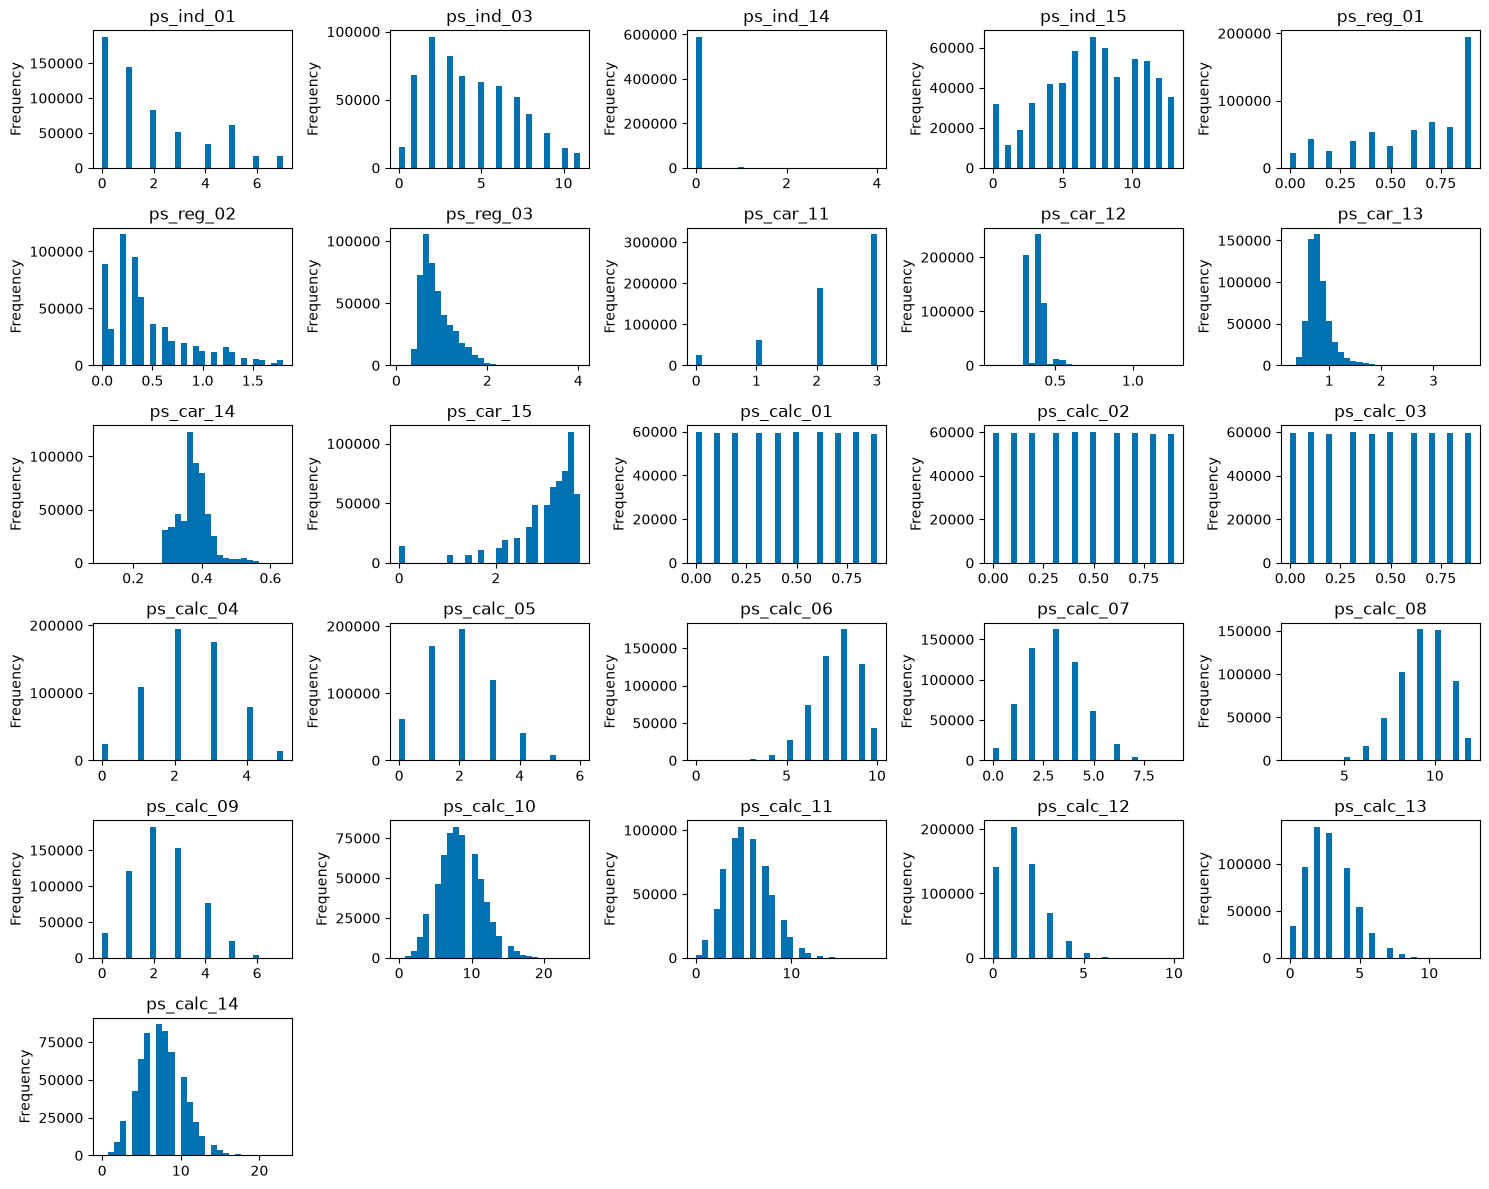

In [195]:
num_cols_grid = 5
num_rows_grid = int(np.ceil(len(num_cols) / num_cols_grid))

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(3*num_cols_grid, 2*num_rows_grid))

achsen = axes.flatten()

for idx, cols in enumerate(num_cols):
    df_raw[cols].dropna().plot(
        kind="hist",
        bins=30,
        ax=achsen[idx]
    )
    achsen[idx].set_title(cols)

for n in range(len(num_cols), len(achsen)):
    achsen[n].axis("off")

plt.tight_layout()


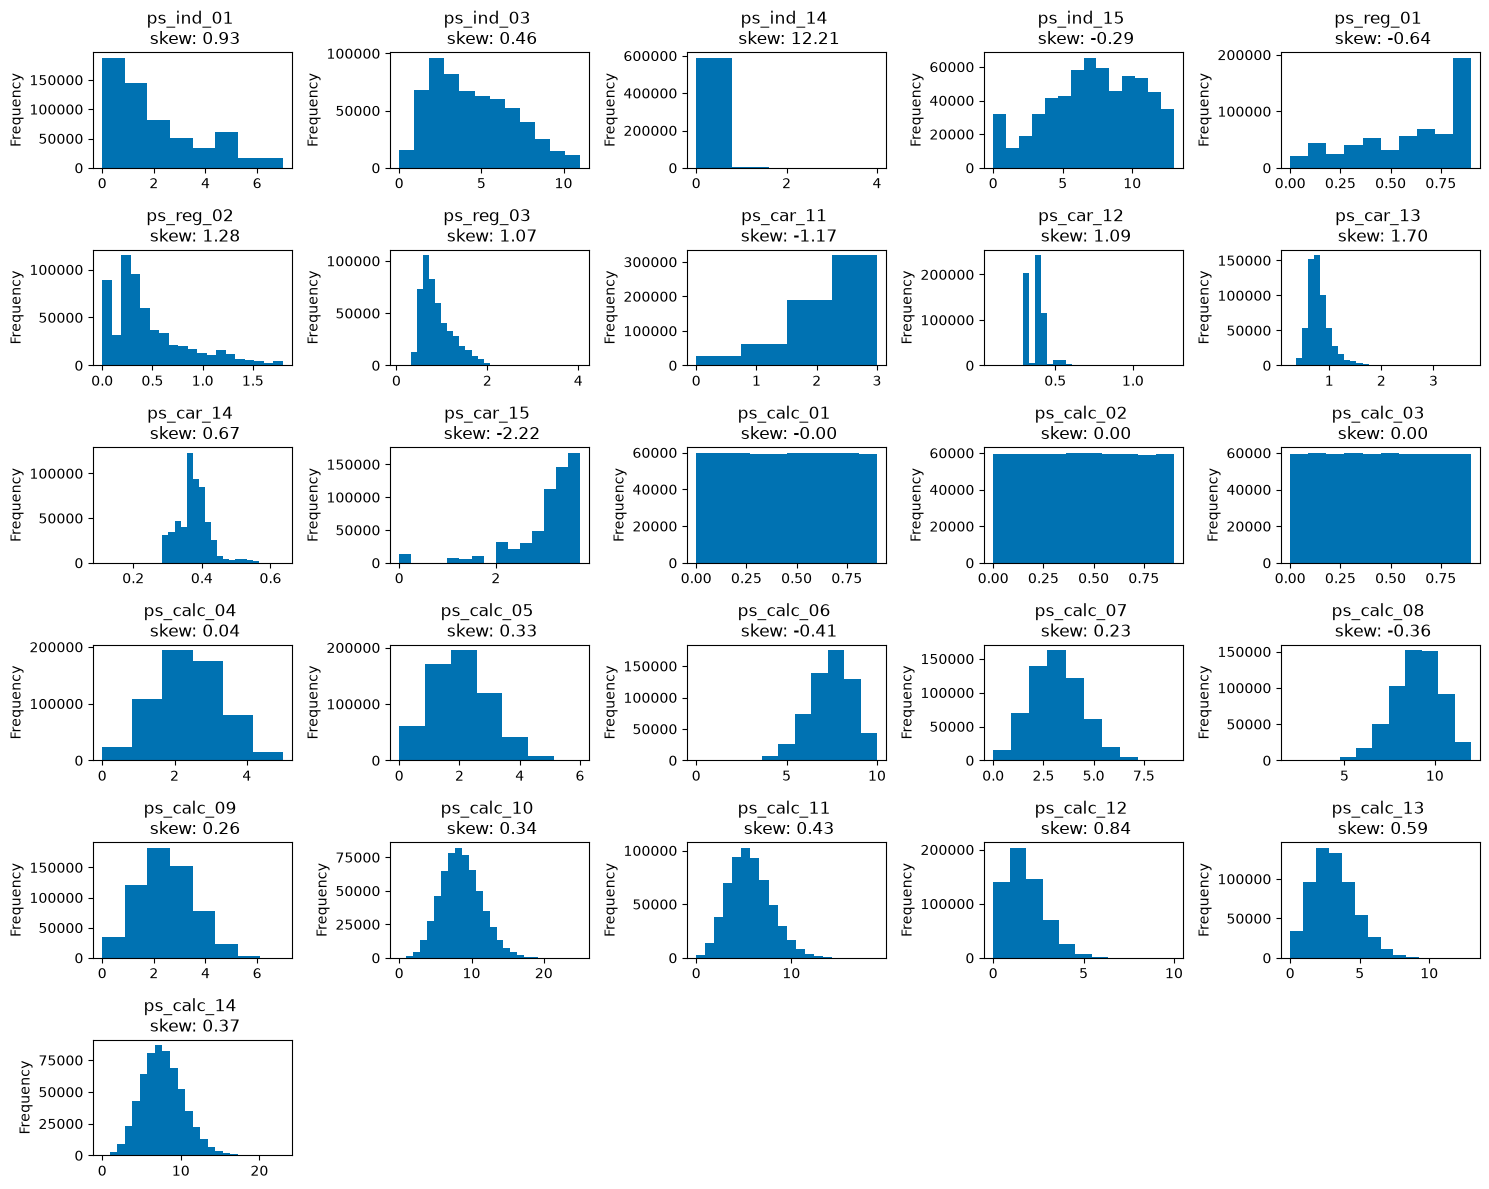

In [198]:
num_cols_grid = 5
num_rows_grid = int(np.ceil(len(num_cols) / num_cols_grid))

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(3*num_cols_grid, 2*num_rows_grid))

achsen = axes.flatten()

for idx, cols in enumerate(num_cols):
    data = df_raw[cols].dropna()
    data_unique = data.nunique()
    data_bins = data_unique if data_unique <= 30 else 30

    data.plot(
        kind="hist",
        bins=data_bins,
        ax=achsen[idx]
    )
    data_skew = data.skew()
    achsen[idx].set_title(f"{cols} \n skew: {data_skew:.2f}")
    achsen[idx].tick_params()

for n in range(len(num_cols), len(achsen)):
    achsen[n].axis("off")

plt.tight_layout()


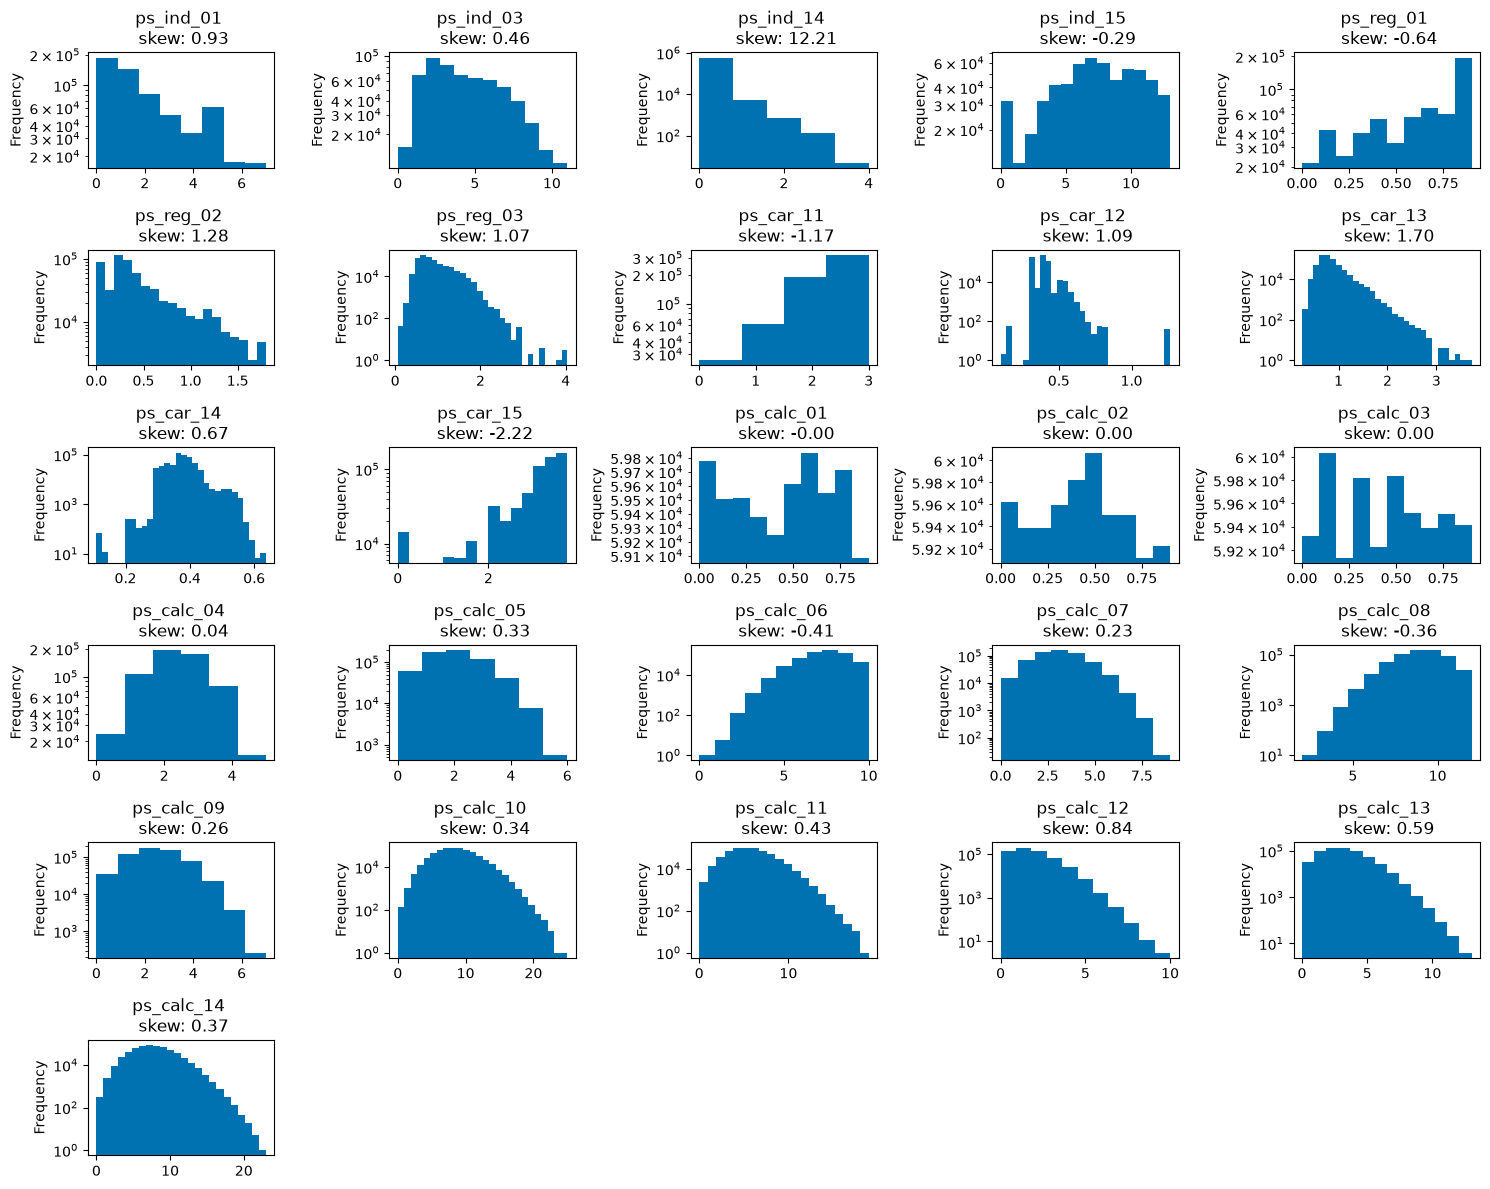

In [199]:
num_cols_grid = 5
num_rows_grid = int(np.ceil(len(num_cols) / num_cols_grid))

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(3*num_cols_grid, 2*num_rows_grid))

achsen = axes.flatten()

for idx, cols in enumerate(num_cols):
    data = df_raw[cols].dropna()
    data_unique = data.nunique()
    data_bins = data_unique if data_unique <= 30 else 30

    data.plot(
        kind="hist",
        bins=data_bins,
        ax=achsen[idx],
        log=True
    )
    data_skew = data.skew()
    achsen[idx].set_title(f"{cols} \n skew: {data_skew:.2f}")
    achsen[idx].tick_params()

for n in range(len(num_cols), len(achsen)):
    achsen[n].axis("off")

plt.tight_layout()


In [ ]:
# einzelne mit je entweder log oder norm

In [207]:
df_raw[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(3)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ps_ind_01,595212.0,1.900,1.984,0.000,0.000,0.000,0.000,1.000,3.000,6.000,7.000,7.000
ps_ind_03,595212.0,4.423,2.700,0.000,0.000,1.000,2.000,4.000,6.000,9.000,11.000,11.000
ps_ind_14,595212.0,0.012,0.128,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,4.000
ps_ind_15,595212.0,7.300,3.546,0.000,0.000,0.000,5.000,7.000,10.000,13.000,13.000,13.000
ps_reg_01,595212.0,0.611,0.288,0.000,0.000,0.100,0.400,0.700,0.900,0.900,0.900,0.900
ps_reg_02,595212.0,0.439,0.404,0.000,0.000,0.000,0.200,0.300,0.600,1.300,1.700,1.800
ps_reg_03,487440.0,0.894,0.345,0.061,0.410,0.492,0.633,0.802,1.084,1.584,1.881,4.038
ps_car_11,595207.0,2.346,0.832,0.000,0.000,1.000,2.000,3.000,3.000,3.000,3.000,3.000
ps_car_12,595211.0,0.380,0.058,0.100,0.316,0.316,0.316,0.374,0.400,0.469,0.566,1.265
ps_car_13,595212.0,0.813,0.225,0.251,0.448,0.543,0.671,0.766,0.906,1.236,1.618,3.721


In [210]:
# nicht interpretierte outlier

def count_outlier(series):
    "außreißer count zurünk geben (außerhalb q1 und q3)"
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_thresh = q1 - 1.5 * iqr
    upper_thresh = q3 + 1.5 * iqr
    return ((series < lower_thresh) | (series > upper_thresh)).sum()

outlier_counts = df_raw[num_cols].apply(count_outlier)

outlier_summary = pd.DataFrame({
    "anzahl_ausreißer": outlier_counts,
    "anteil": outlier_counts / len(df_raw)
})

outlier_summary.sort_values("anzahl_ausreißer", ascending=False)

,anzahl_ausreißer,anteil
ps_calc_04,38105,0.064019
ps_reg_02,36793,0.061815
ps_calc_12,35259,0.059238
ps_car_15,27409,0.046049
ps_car_13,26913,0.045216
ps_car_11,25983,0.043653
ps_car_14,18770,0.031535
ps_calc_14,16086,0.027026
ps_car_12,15355,0.025798
ps_reg_03,10562,0.017745


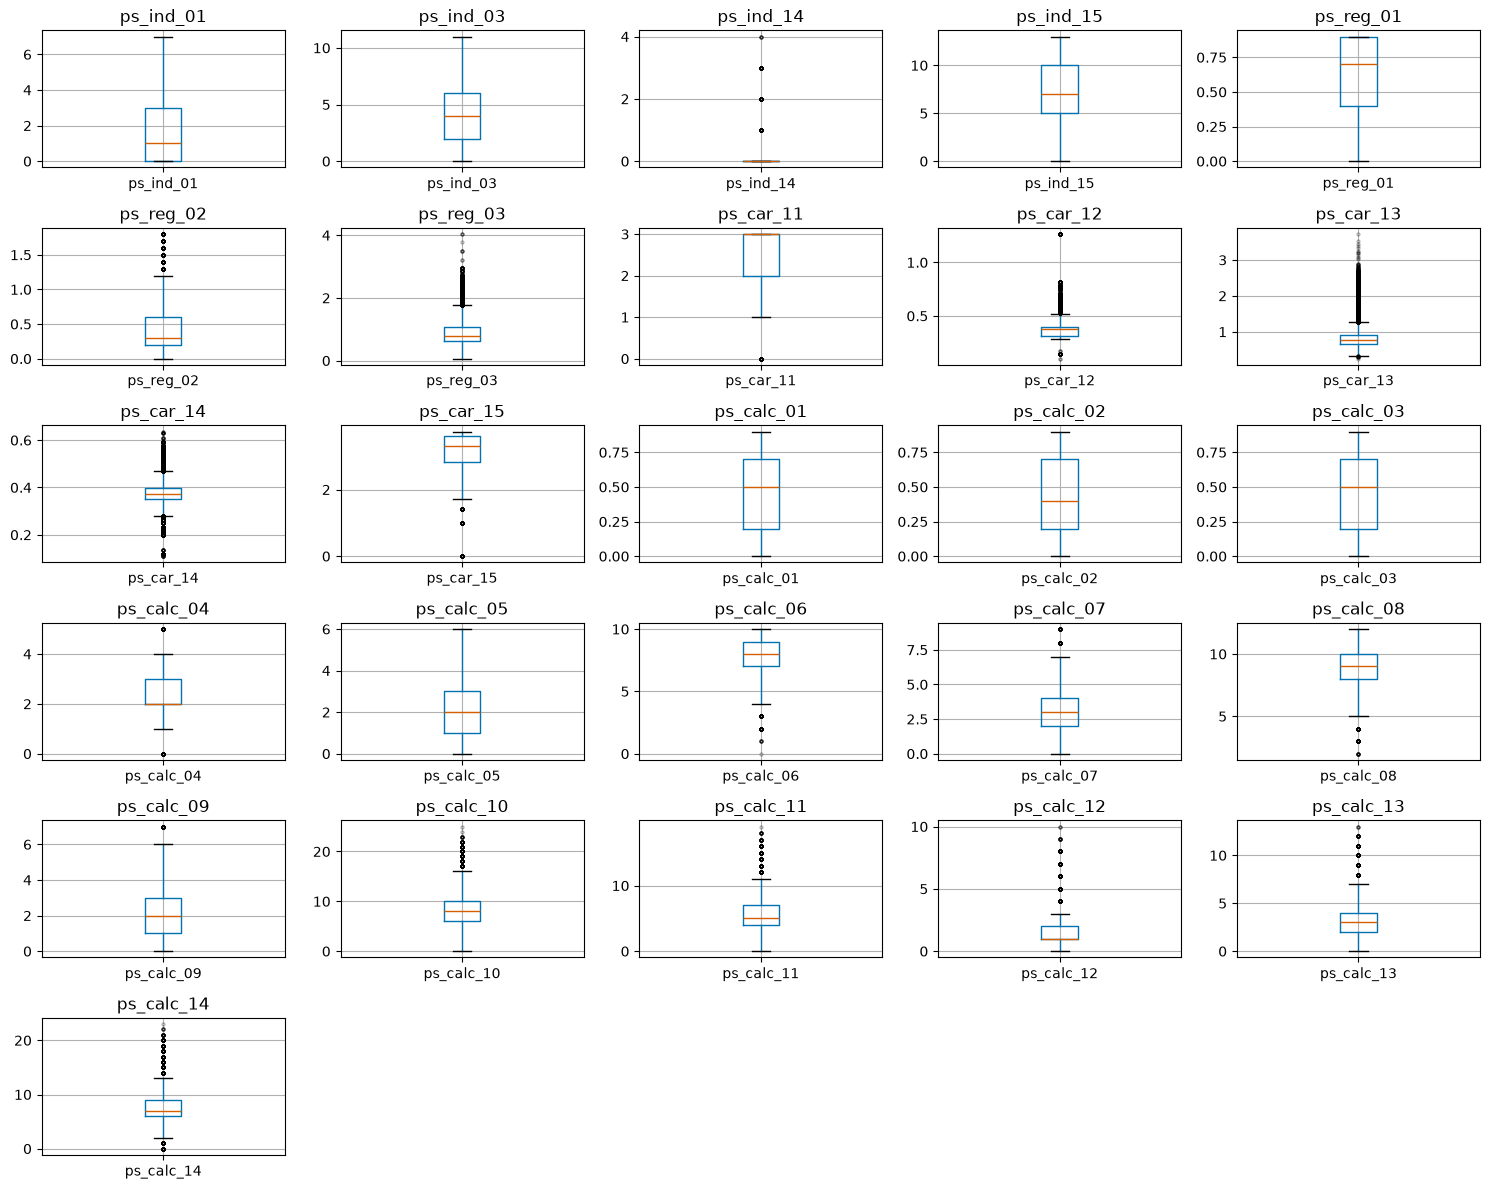

In [201]:
fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(3*num_cols_grid, 2*num_rows_grid))

achsen = axes.flatten()

for idx, cols in enumerate(num_cols):
    df_raw.boxplot(
        column=cols,
        ax=achsen[idx],
        flierprops=dict(
            marker="o",
            markersize=2,
            alpha=0.3,
        )
    )
    achsen[idx].set_title(cols)
    achsen[idx].set_xlabel("")

for n in range(len(num_cols), len(achsen)):
    achsen[n].axis("off")

plt.tight_layout()

ps_car_13     0.053899
ps_car_12     0.038800
ps_reg_02     0.034800
ps_reg_03     0.033758
ps_car_15     0.027667
ps_reg_01     0.022888
ps_ind_15    -0.021506
ps_ind_01     0.018570
ps_car_14     0.011674
ps_ind_03     0.008360
ps_ind_14     0.007443
ps_calc_03    0.001907
ps_calc_01    0.001782
ps_calc_14    0.001362
ps_calc_02    0.001360
ps_car_11    -0.001220
ps_calc_12   -0.001133
ps_calc_10    0.001061
ps_calc_08   -0.001006
ps_calc_05    0.000771
ps_calc_09    0.000719
ps_calc_13   -0.000446
ps_calc_11    0.000371
ps_calc_07   -0.000103
ps_calc_06    0.000082
ps_calc_04    0.000033
Name: target, dtype: float64


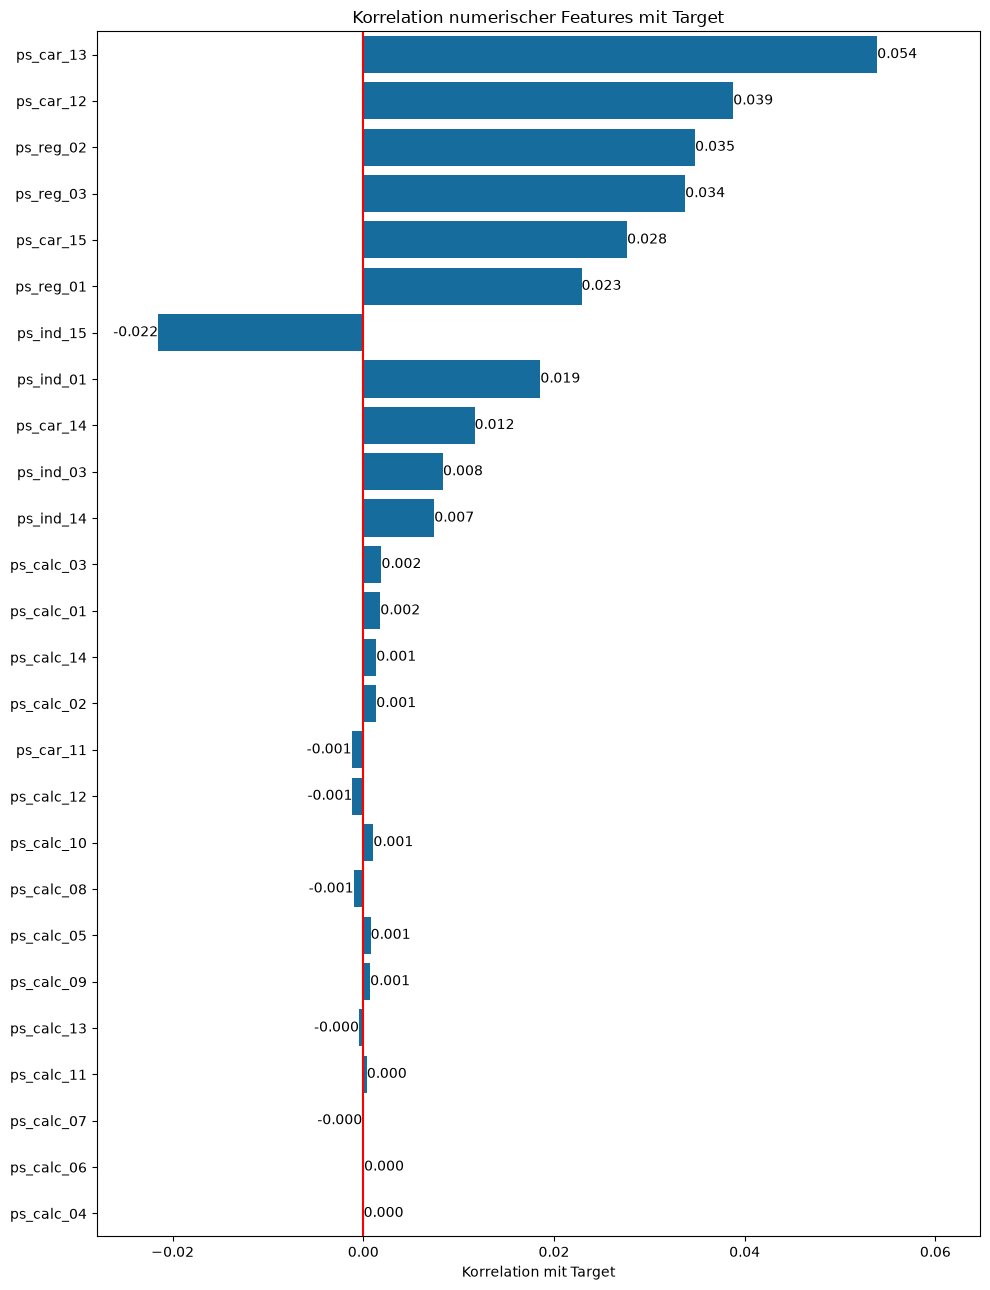

In [257]:
corr_num_target = (
    df_raw[num_cols]
    .assign(target=df_raw["target"].astype(float))
    .corr()["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, max(3, 0.5*len(corr_num_target))))

sns.barplot(
    x=corr_num_target.values,
    y=corr_num_target.index,
    ax=ax,
    orient="h"
)
ax.axvline(0, color="red")
ax.set_title("Korrelation numerischer Features mit Target")
ax.set_xlabel("Korrelation mit Target")
ax.set_ylabel("")
ax.set_xlim(min(corr_num_target)*1.3, max(corr_num_target)*1.2)

for container in ax.containers:
    labels = [f"{v:.3f}" for v in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.tight_layout()

print(corr_num_target)

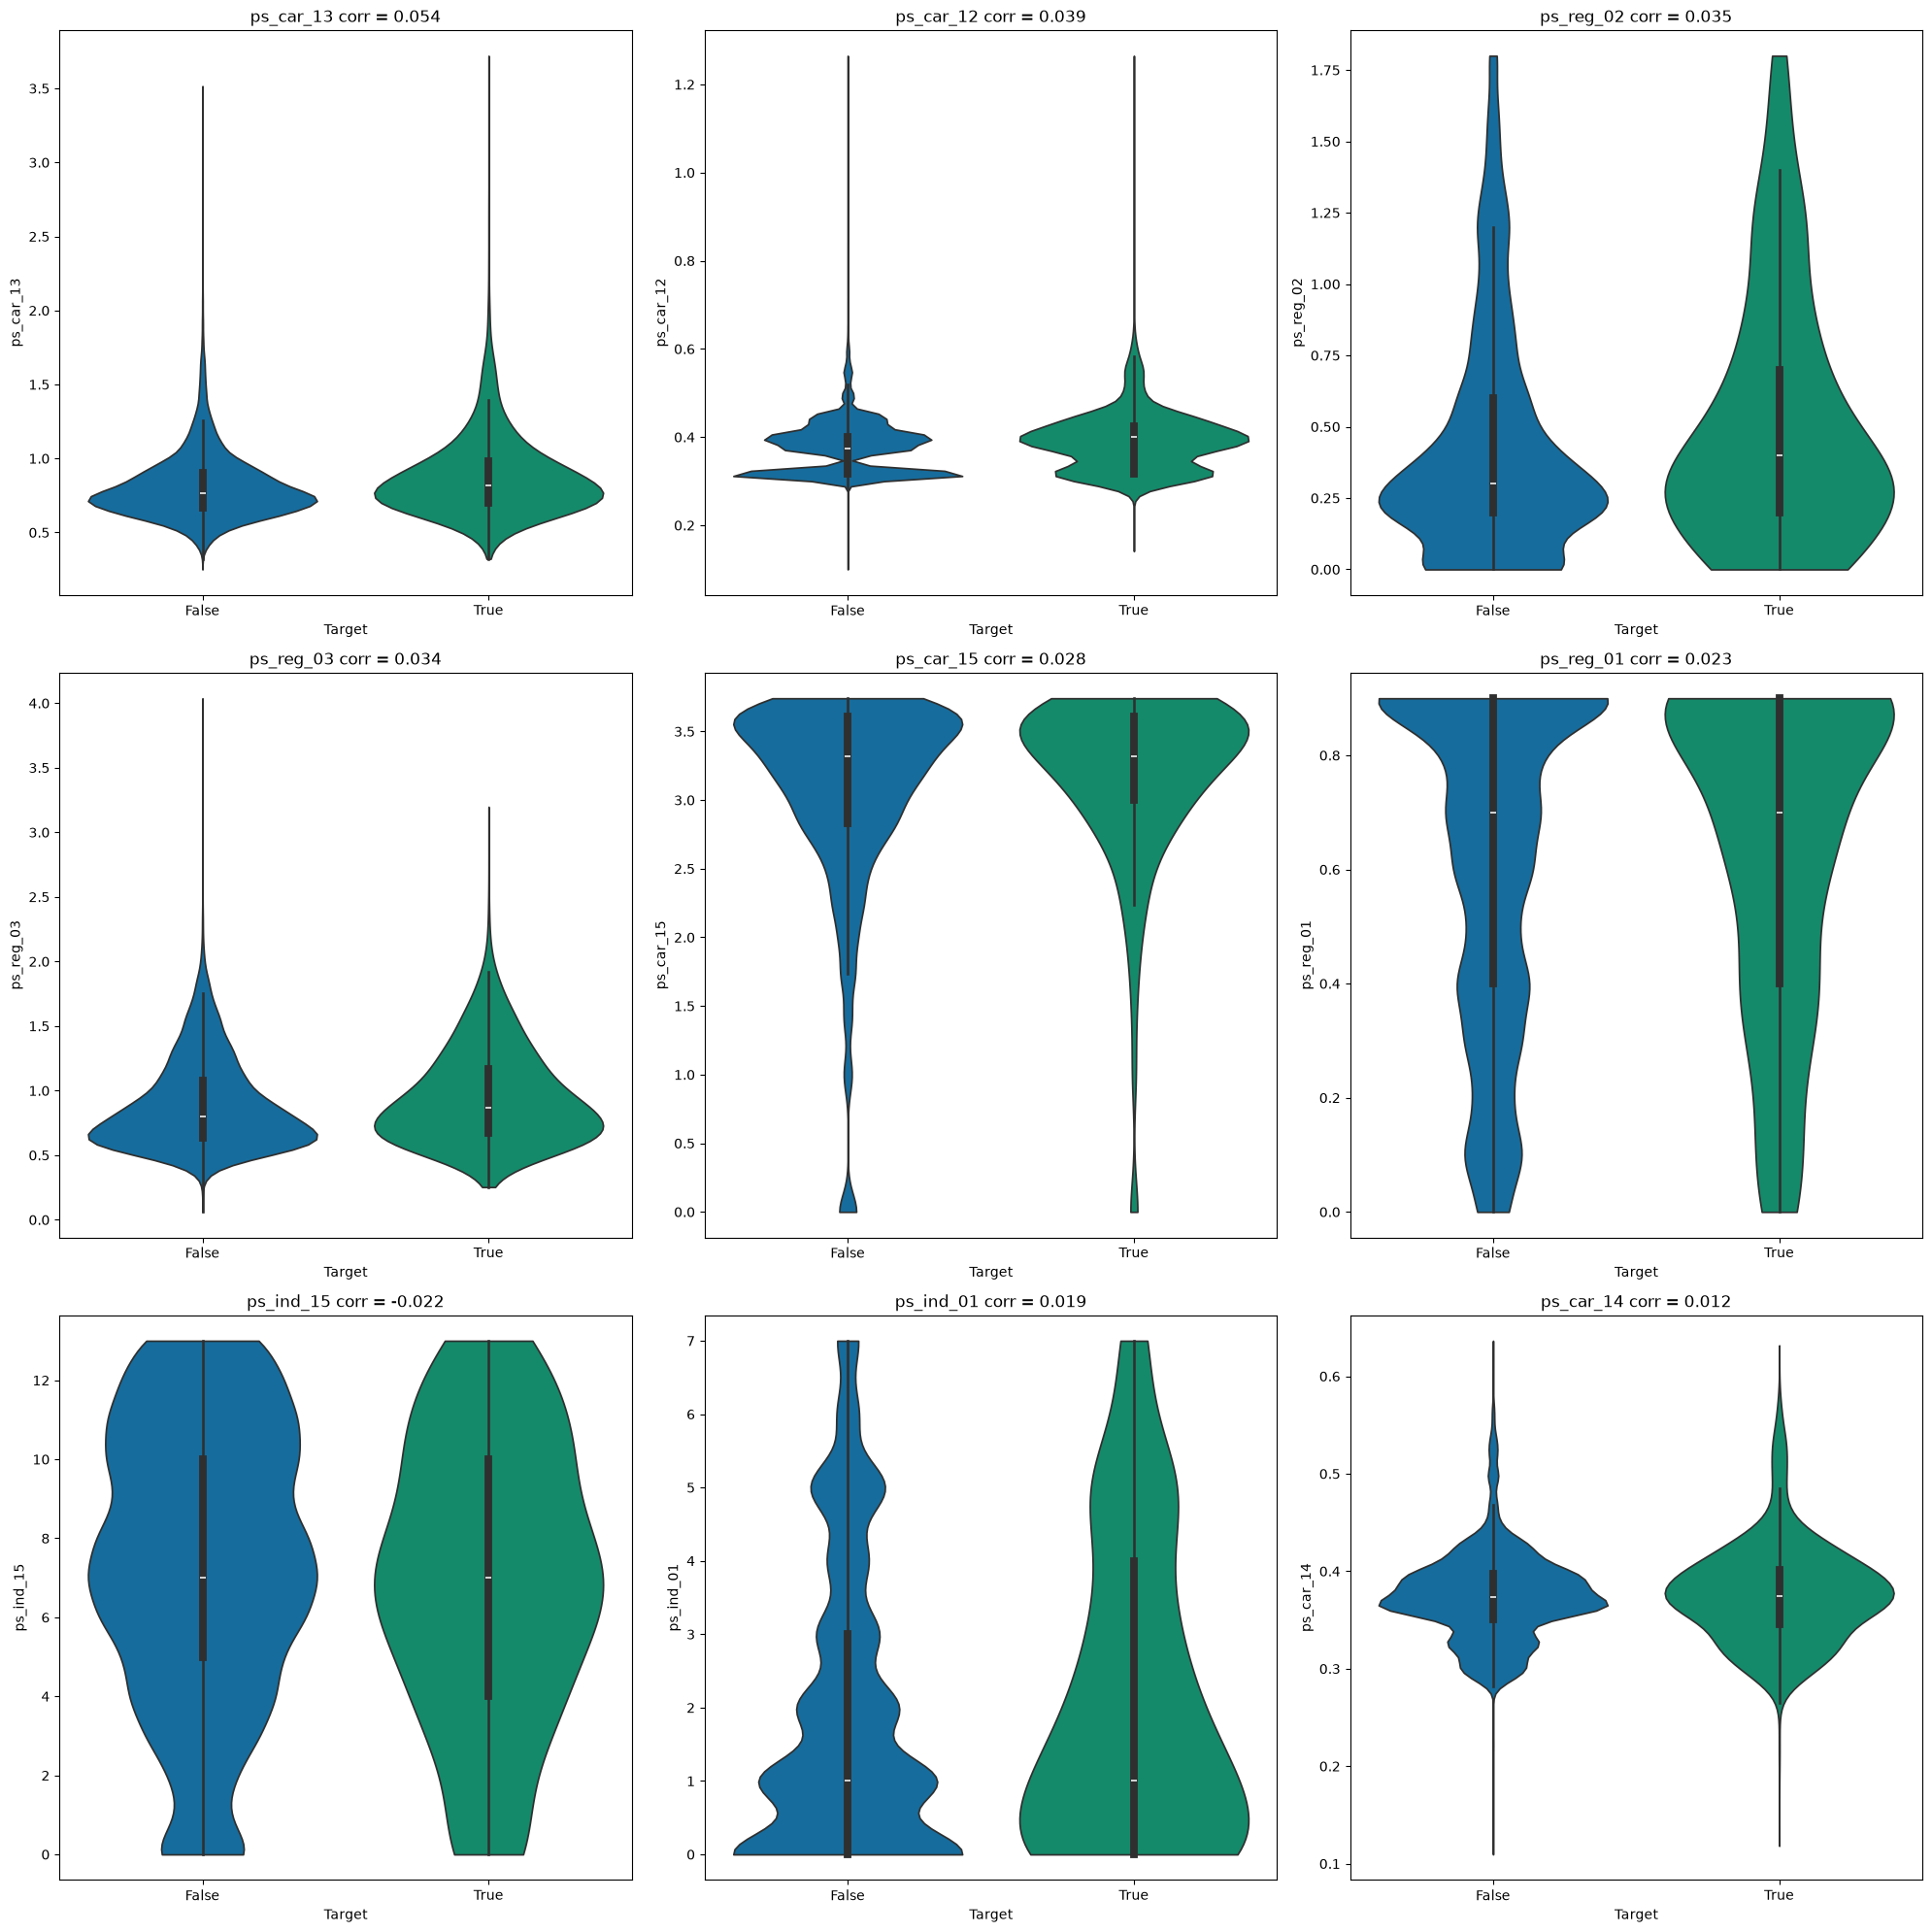

In [227]:
top_corr_feats = corr_num_target.abs().sort_values(ascending=False).head(9).index

fig, axes = plt.subplots(3, 3, figsize=(20, 20))

achsen = axes.flatten()

for idx, cols in enumerate(top_corr_feats):
    sns.violinplot(
        x="target",
        y=cols,
        data=df_raw,
        ax=achsen[idx],
        legend=False,
        common_norm=False,
        hue="target",
        bw_adjust=2.5,
        cut=0
    )
    achsen[idx].set_title(f"{cols} corr = {corr_num_target[cols]:.3f}")
    achsen[idx].set_xlabel("Target")

plt.tight_layout()

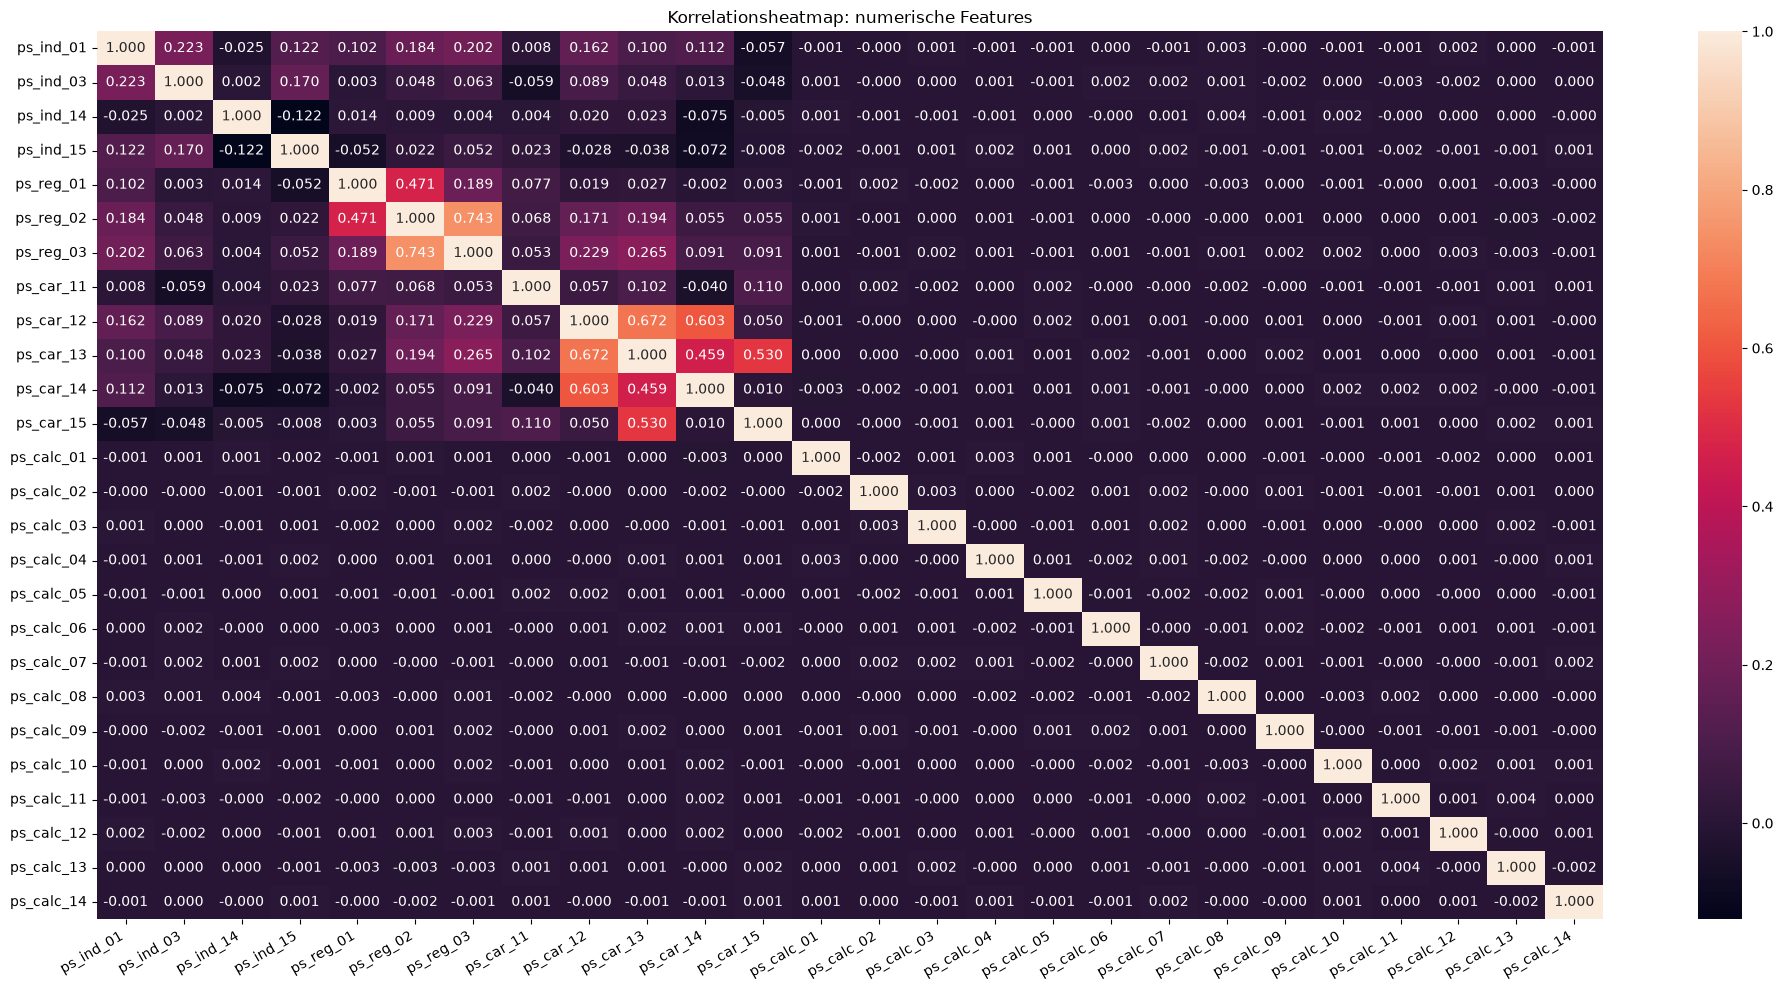

In [233]:
fig, ax = plt.subplots(figsize=(20,10))

sns.heatmap(
    df_raw[num_cols].corr(),
    ax=ax,
    xticklabels=True,
    yticklabels=True,
    annot=True,
    fmt=".3f"
)
ax.set_title("Korrelationsheatmap: numerische Features")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()

In [240]:
corr_num_matrix = df_raw[num_cols].corr()

corr_num_pairs = corr_num_matrix.where(
    np.triu(np.ones(corr_num_matrix.shape, dtype=bool), k=1)
).stack()

corr_num_pairs = corr_num_pairs[corr_num_pairs.abs() > 0.2].sort_values(key=abs, ascending=False)

corr_num_pairs_df = corr_num_pairs.reset_index()
corr_num_pairs_df.columns = ["feature_1", "feature_2", "corr"]
corr_num_pairs_df

,feature_1,feature_2,corr
0,ps_reg_02,ps_reg_03,0.742668
1,ps_car_12,ps_car_13,0.672014
2,ps_car_12,ps_car_14,0.603361
3,ps_car_13,ps_car_15,0.529519
4,ps_reg_01,ps_reg_02,0.471027
5,ps_car_13,ps_car_14,0.459047
6,ps_reg_03,ps_car_13,0.264800
7,ps_reg_03,ps_car_12,0.228926
8,ps_ind_01,ps_ind_03,0.223408
9,ps_ind_01,ps_reg_03,0.202096


In [239]:
corr_num_matrix = df_raw[num_cols].corr()

corr_num_pairs = corr_num_matrix.where(
    np.triu(np.ones(corr_num_matrix.shape, dtype=bool), k=1)
).stack()

corr_num_pairs = corr_num_pairs[corr_num_pairs.abs() > 0.5].sort_values(key=abs, ascending=False)

corr_num_pairs_df = corr_num_pairs.reset_index()
corr_num_pairs_df.columns = ["feature_1", "feature_2", "corr"]
corr_num_pairs_df

,feature_1,feature_2,corr
0,ps_reg_02,ps_reg_03,0.742668
1,ps_car_12,ps_car_13,0.672014
2,ps_car_12,ps_car_14,0.603361
3,ps_car_13,ps_car_15,0.529519


In [ ]:
#calc scheint kaum korrs mit target aufzuweisen deshalb nochmal
calc_num_cols = [cols for cols in num_cols if cols.startswith("ps_calc_")]

calc_num_corr_target = corr_num_target[calc_num_cols].sort_values(key=abs, ascending=False)

print("Korrelation calc_ num features Target:")
print(calc_num_corr_target)


Korrelation calc_ num features Target:
ps_calc_03    0.001907
ps_calc_01    0.001782
ps_calc_14    0.001362
ps_calc_02    0.001360
ps_calc_12   -0.001133
ps_calc_10    0.001061
ps_calc_08   -0.001006
ps_calc_05    0.000771
ps_calc_09    0.000719
ps_calc_13   -0.000446
ps_calc_11    0.000371
ps_calc_07   -0.000103
ps_calc_06    0.000082
ps_calc_04    0.000033
Name: target, dtype: float64


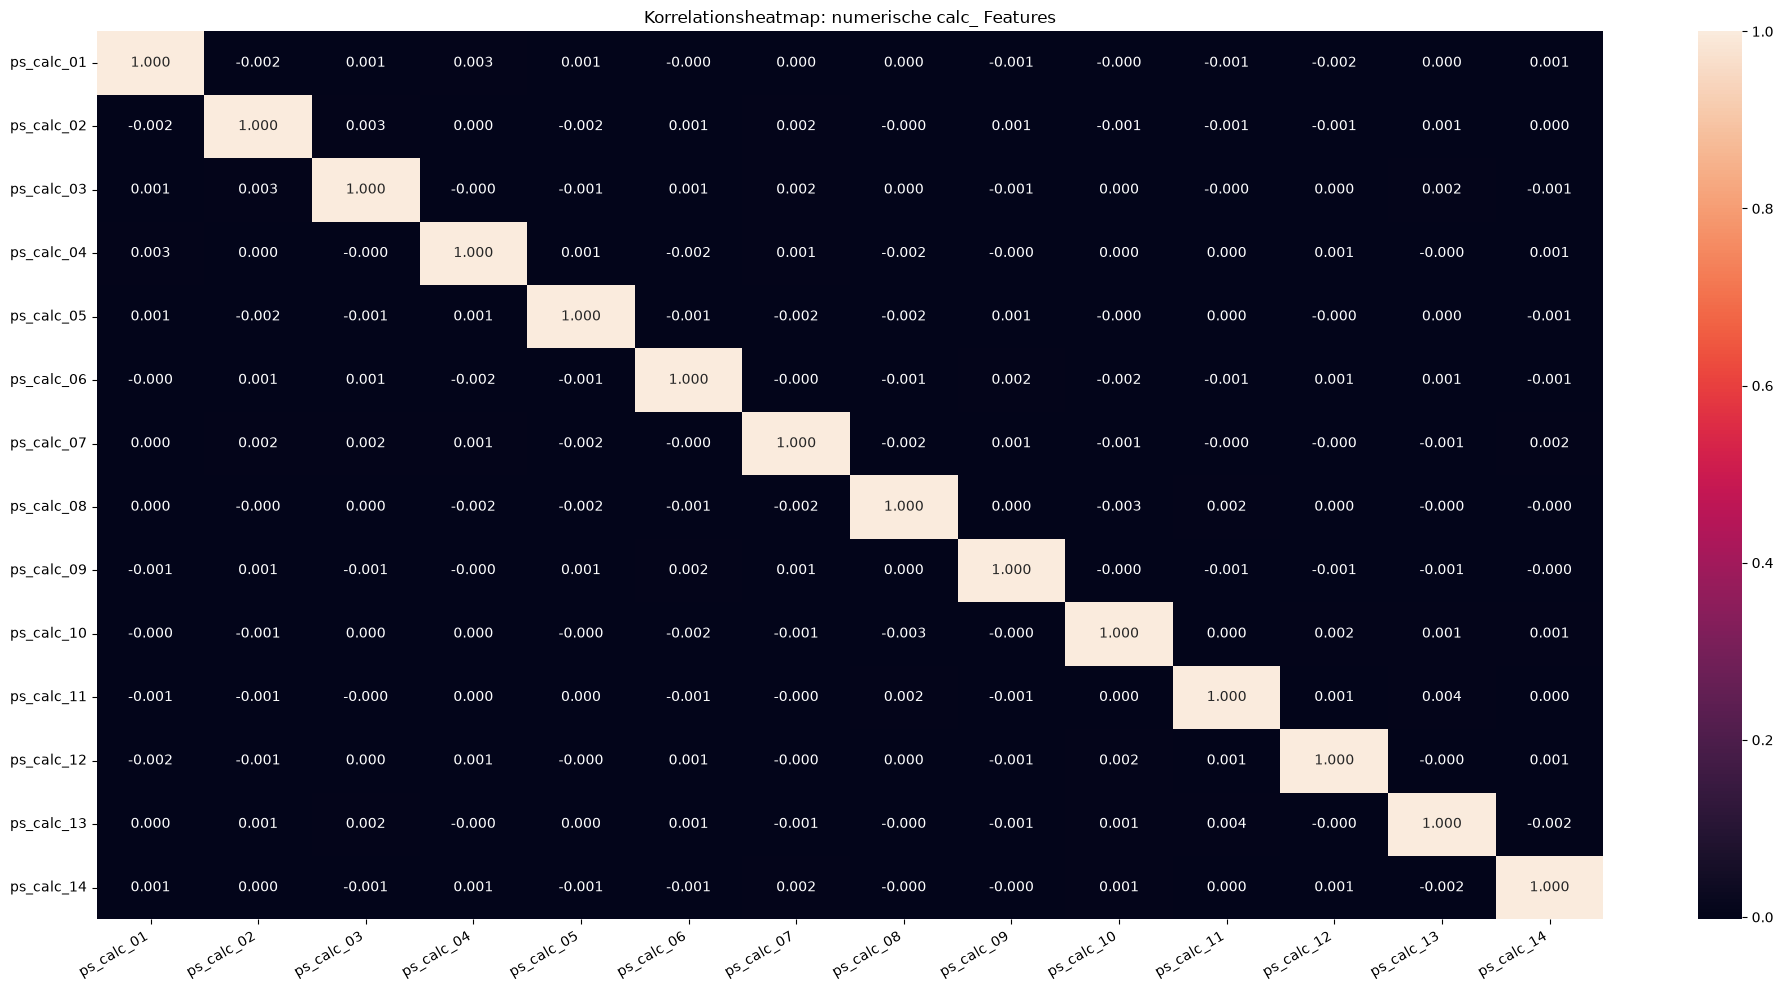

In [243]:
fig, ax = plt.subplots(figsize=(20,10))

sns.heatmap(
    df_raw[calc_num_cols].corr(),
    ax=ax,
    xticklabels=True,
    yticklabels=True,
    annot=True,
    fmt=".3f"
)
ax.set_title("Korrelationsheatmap: numerische calc_ Features")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()

## Duplikate

In [244]:
duplikat_n = df_raw.duplicated().sum()
print(f"Anzahl doppelter Zeilen: {duplikat_n}")

Anzahl doppelter Zeilen: 0


## gegebene Gruppen überprüfen

In [245]:
prefix_groups = {}
for prefix in {"ind", "reg", "car", "calc"}:
    prefix_groups[prefix] = [cols for cols in feat_cols if cols.startswith(f"ps_{prefix}_")]
    print(f"ps_{prefix}_: {len(prefix_groups[prefix])} Columns")

ps_reg_: 3 Columns
ps_ind_: 18 Columns
ps_calc_: 20 Columns
ps_car_: 16 Columns


In [248]:
for prefix, cols in prefix_groups.items():
    cols_num = [col for col in cols if col in num_cols]
    cols_bin = [col for col in cols if col in bin_cols]
    cols_cat = [col for col in cols if col in cat_cols]

    print(f"Für {prefix} :")
    print(f"num: {len(cols_num)}")
    print(f"bin: {len(cols_bin)}")
    print(f"cat: {len(cols_cat)}")

    compatible_cols = cols_num + cols_bin
    if len(compatible_cols) >= 2:
        korr = df_raw[compatible_cols].astype(float).corr()
        max_korr = korr.where(np.triu(np.ones(korr.shape, dtype=bool), k=1)).abs().max().max()
        print(f"max korr num/bin: {max_korr:.3f}" if pd.notna(max_korr) else "  nur 1 Feature")
    
    if len(cols_cat) >= 2:
        print(f"{len(cols_cat)} cat features: Cramers V prüfen")

Für reg :
num: 3
bin: 0
cat: 0
max korr num/bin: 0.743
Für ind :
num: 4
bin: 11
cat: 3
max korr num/bin: 0.890
3 cat features: Cramers V prüfen
Für calc :
num: 14
bin: 6
cat: 0
max korr num/bin: 0.004
Für car :
num: 5
bin: 0
cat: 11
max korr num/bin: 0.672
11 cat features: Cramers V prüfen


In [258]:
result_pairs = []

for prefix in ["reg", "ind", "car"]:
    cols = prefix_groups[prefix]
    compatible_cols = [col for col in cols if col in num_cols + bin_cols]
    korr = df_raw[compatible_cols].astype(float).corr()

    pairs = korr.where(np.triu(np.ones(korr.shape, dtype=bool), k=1)).stack()
    pairs = pairs[pairs.abs() > 0.5]

    for (col1, col2), v in pairs.items():
        result_pairs.append({
            "prefix": f"ps_{prefix}_", 
            "feature_1": col1,
            "feature_2": col2,
            "korr": v
        })

result_pairs_df = pd.DataFrame(result_pairs).sort_values("korr", key=abs, ascending=False)
result_pairs_df

,prefix,feature_1,feature_2,korr
2,ps_ind_,ps_ind_12_bin,ps_ind_14,0.890127
0,ps_reg_,ps_reg_02,ps_reg_03,0.742668
5,ps_car_,ps_car_12,ps_car_13,0.672014
6,ps_car_,ps_car_12,ps_car_14,0.603361
4,ps_ind_,ps_ind_16_bin,ps_ind_18_bin,-0.594265
1,ps_ind_,ps_ind_11_bin,ps_ind_14,0.564903
7,ps_car_,ps_car_13,ps_car_15,0.529519
3,ps_ind_,ps_ind_16_bin,ps_ind_17_bin,-0.518076


In [255]:
def cramers_v(x,y):
    """eigene cramer v über kreuztabelle und chi2"""
    conti = pd.crosstab(x,y)
    chi_2 = chi2_contingency(conti)[0]
    n = conti.sum().sum()
    r, k = conti.shape
    return np.sqrt(chi_2 / (n * (min(r,k) - 1)))

reslut_cramer = []

for prefix in ["ind", "car"]:
    cols_cat = [col for col in prefix_groups[prefix] if col in cat_cols]
    for col1, col2 in itertools.combinations(cols_cat, 2):
        v = cramers_v(df_raw[col1], df_raw[col2])
        reslut_cramer.append({
            "prefix": f"ps_{prefix}_", 
            "feature_1": col1,
            "feature_2": col2,
            "cramers_v": v
        })

cramers_df = pd.DataFrame(reslut_cramer).sort_values("cramers_v", ascending=False)
cramers_df

,prefix,feature_1,feature_2,cramers_v
47,ps_car_,ps_car_06_cat,ps_car_11_cat,0.722217
21,ps_car_,ps_car_02_cat,ps_car_11_cat,0.618692
16,ps_car_,ps_car_02_cat,ps_car_06_cat,0.540172
36,ps_car_,ps_car_04_cat,ps_car_11_cat,0.531340
54,ps_car_,ps_car_08_cat,ps_car_11_cat,0.474741
26,ps_car_,ps_car_03_cat,ps_car_08_cat,0.419515
10,ps_car_,ps_car_01_cat,ps_car_09_cat,0.379092
14,ps_car_,ps_car_02_cat,ps_car_04_cat,0.378184
31,ps_car_,ps_car_04_cat,ps_car_06_cat,0.331320
29,ps_car_,ps_car_03_cat,ps_car_11_cat,0.318508


# Ergebnisse der EDA